<!-- # 0. library import & Data load -->

In [1]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import datetime
from warnings import simplefilter
from functools import partial

from tqdm.auto import tqdm
import datetime as dt
from pathlib import Path

tqdm.pandas()

simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
simplefilter(action="ignore", category=pd.errors.DtypeWarning)
pd.set_option('display.max_columns', None)

from pandarallel import pandarallel
pandarallel.initialize()

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [6]:
# research path
root_dir = '/home/DAHS1/gangmin/my_research/'

# data path
core_mimiciv_path = "/home/DAHS1/gangmin/my_research/data/mimic-iv/"
# core_mimiciv_imgcxr_path = 'C:/Users/gangmin/dahs/data/physionet.org/files/mimic-cxr-jpg/2.1.0/'

In [7]:
# core
df_admissions = pd.read_parquet(core_mimiciv_path + 'core/parquet/admissions.parquet')
df_patients = pd.read_parquet(core_mimiciv_path + 'core/parquet/patients.parquet')
df_transfers = pd.read_parquet(core_mimiciv_path + 'core/parquet/transfers.parquet')

In [8]:
# hosp
df_diagicd = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/diagnoses_icd.parquet")
df_procicd = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/procedures_icd.parquet")
df_lab = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/labevents.parquet")
df_prscr = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/prescriptions.parquet")
df_micro = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/microbiologyevents.parquet")
df_omr = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/omr.parquet")
df_dlabitems = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/d_labitems.parquet")

In [9]:
# icu
df_icustays = pd.read_parquet(core_mimiciv_path + '/icu/parquet/icustays.parquet')
df_chart = pd.read_parquet(core_mimiciv_path + "/icu/parquet/chartevents.parquet")
df_input = pd.read_parquet(core_mimiciv_path + "/icu/parquet/inputevents.parquet")
df_output = pd.read_parquet(core_mimiciv_path + "/icu/parquet/outputevents.parquet")
df_proc = pd.read_parquet(core_mimiciv_path + "/icu/parquet/procedureevents.parquet")
df_ditems = pd.read_parquet(core_mimiciv_path + "/icu/parquet/d_items.parquet")

In [10]:
# cxr
df_mimic_cxr_chexpert = pd.read_csv('/home/DAHS1/gangmin/my_research/data/mimic-cxr-2.0.0-chexpert.csv')
df_mimic_cxr_metadata = pd.read_csv('/home/DAHS1/gangmin/my_research/data/mimic-cxr-2.0.0-metadata.csv')

In [11]:
# df_mimic_cxr_chexpert.head()

In [12]:
# df_mimic_cxr_metadata.head()

In [13]:
# unnecessary column drop
df_chart = df_chart.drop(columns=['storetime', 'warning', 'caregiver_id'])

tmp = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'amount', 'amountuom', 'rate', 'rateuom', 'patientweight']
df_input = df_input.drop(columns=[col for col in df_input.columns if col not in tmp])

df_output = df_output.drop(columns=['storetime', 'caregiver_id'])

tmp = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'value', 'valueuom', 'patientweight']
df_proc = df_proc.drop(columns=[col for col in df_proc.columns if col not in tmp])

tmp = ['subject_id', 'hadm_id', 'specimen_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom']
df_lab = df_lab.drop(columns=[col for col in df_lab.columns if col not in tmp])

tmp = ['subject_id', 'hadm_id', 'starttime', 'stoptime', 'drug']
df_prscr = df_prscr.drop(columns=[col for col in df_prscr.columns if col not in tmp])
df_prscr.columns = [col if col != 'stoptime' else 'endtime' for col in df_prscr.columns]

tmp = ['subject_id', 'hadm_id', 'charttime', 'spec_type_desc', 'org_name'] # spec_itemid -> spec_type_desc, 
df_micro = df_micro.drop(columns = [col for col in df_micro.columns if col not in tmp])
df_micro.columns = [col if col != 'spec_type_desc' else 'itemid' for col in df_micro.columns ]

<!-- # 1. Extract cxr within ICU -->

In [14]:
# 각 데이터셋에 포함된 여러 시간 정보를 str 자료형에서 datetime 자료형으로 변경
df_list = [df_admissions, df_transfers, df_icustays, df_chart, df_input, df_proc, df_output, df_procicd, df_lab, df_prscr, df_micro, df_omr]

for df in tqdm(df_list):
    # chart, output, lab, microbiology 
    if 'charttime' in df.columns:
        df['charttime'] = pd.to_datetime(df['charttime'])
        df = df.sort_values(['subject_id', 'charttime']).reset_index(drop=True)
    
    # input, procedure, prescription
    elif 'endtime' in df.columns:
        df['starttime'] = pd.to_datetime(df['starttime'])
        df['endtime'] = pd.to_datetime(df['endtime'])
        df = df.sort_values(['subject_id', 'starttime']).reset_index(drop=True)

    # admission, 
    elif 'admittime' in df.columns:
        df['admittime'] = pd.to_datetime(df['admittime'])
        df['dischtime'] = pd.to_datetime(df['dischtime'])
        df = df.sort_values(['subject_id', 'admittime']).reset_index(drop=True)
    
    # procicd, omr
    elif 'chartdate' in df.columns:
        df['chartdate'] = pd.to_datetime(df['chartdate'])
        df = df.sort_values(['subject_id', 'chartdate']).reset_index(drop=True)

    # transfers, icustays
    elif 'intime' in df.columns:
        df['intime'] = pd.to_datetime(df['intime'])
        df['outtime'] = pd.to_datetime(df['outtime'])
        df = df.sort_values(['subject_id', 'intime']).reset_index(drop=True)

  0%|          | 0/12 [00:00<?, ?it/s]

<!-- - mimic-cxr에는 hadm_id와 stay_id가 없으므로 cxrtime을 통해서 hadm_id와 stay_id의 할당이 필요함. -->

In [15]:
# hadm 할당 함수
def assign_hadm_id(row, df):
    hadm_records = df[df['subject_id'] == row['subject_id']]

    for idx, record in hadm_records.iterrows():
        if record['admittime'] <= row['cxrtime'] <= record['dischtime']:
            return record['hadm_id']
    return None

In [16]:
# stay_id 할당 함수
def assign_stay_id(row, df):
    icu_records = df[(df['subject_id'] == row['subject_id']) & (df['hadm_id']==row['hadm_id'])]
    
    for idx, record in icu_records.iterrows():
        if record['intime'] <= row['cxrtime'] <= record['outtime']: # icu니까 intime, outime 기준
            return record['stay_id'] 
    return None

In [17]:
df_meta = df_mimic_cxr_metadata.copy()

df_meta['StudyDateForm'] = pd.to_datetime(df_meta['StudyDate'], format='%Y%m%d')
df_meta['StudyTimeForm'] = df_meta.apply(lambda x : '%#010.3f' % x['StudyTime'] ,1)
df_meta['StudyTimeForm'] = pd.to_datetime(df_meta['StudyTimeForm'], format='%H%M%S.%f').dt.time
df_meta['cxrtime'] = df_meta.apply(lambda r : dt.datetime.combine(r['StudyDateForm'],r['StudyTimeForm']), 1)

In [18]:
# cxr 파일별 경로 담겨 있음.
cxr_txt_path = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/image_filenames.parquet")

In [19]:
cxr_txt_path.rename(columns={'text': 'file_path'}, inplace=True)

# dicom_id 추출: 마지막 '/' 이후 문자열
cxr_txt_path['dicom_id'] = cxr_txt_path['file_path'].str.extract(r'/([^/]+)\.jpg$')

In [20]:
cxr_txt_path.head()

,file_path,dicom_id
0,files/p10/p10000032/s50414267/02aa804e-bde0afd...,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014
1,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962
2,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab
3,files/p10/p10000032/s53189527/e084de3b-be89b11...,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c
4,files/p10/p10000032/s53911762/68b5c4b1-227d048...,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714


In [21]:
df_cxr = pd.merge(cxr_txt_path, df_meta, on='dicom_id')

In [22]:
df_cxr['ViewPosition'].value_counts()

ViewPosition
AP                147173
PA                 96161
LATERAL            82853
LL                 35133
PA LLD                 4
LAO                    3
RAO                    3
AP AXIAL               2
AP LLD                 2
XTABLE LATERAL         2
AP RLD                 2
SWIMMERS               1
PA RLD                 1
LPO                    1
Name: count, dtype: int64

In [23]:
df_cxr = df_cxr[['dicom_id', 'subject_id', 'study_id', 'ViewPosition', 'cxrtime']]
df_cxr = df_cxr[(df_cxr['ViewPosition']=='PA') | (df_cxr['ViewPosition']=='AP')].reset_index(drop=True) # ICU 환자는 AP만 사용하기도 하지만 일단 PA도 포함시킴. (24만장)

In [24]:
df_cxr

,dicom_id,subject_id,study_id,ViewPosition,cxrtime
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,PA,2180-05-06 21:30:14.531
1,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,PA,2180-06-26 16:55:00.312
2,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,AP,2180-07-23 08:05:56.875
3,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,10000032,53911762,AP,2180-07-23 08:05:56.875
4,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,10000032,56699142,AP,2180-08-05 23:44:24.765
...,...,...,...,...,...
243329,3fcd0406-9b111603-feae7033-96632b3a-111333e5,19999733,57132437,PA,2152-07-08 22:45:50.171
243330,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,19999733,57132437,PA,2152-07-08 22:45:50.171
243331,58766883-376a15ce-3b323a28-6af950a0-16b793bd,19999987,55368167,AP,2145-11-04 05:14:48.218
243332,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08,19999987,58621812,AP,2145-11-02 20:28:09.234


In [25]:
df_mimic_cxr_image = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/image_filenames.parquet")

if 'file_path' in df_mimic_cxr_image.columns:
    # 경로에서 폴더와 파일명 분리
    df_mimic_cxr_image['Img_Folder'] = df_mimic_cxr_image['file_path'].str.rsplit('/', n=1).str[0]
    df_mimic_cxr_image['Img_Filename'] = df_mimic_cxr_image['file_path'].str.rsplit('/', n=1).str[1]

    # dicom_id 추출
    df_mimic_cxr_image['dicom_id'] = df_mimic_cxr_image['Img_Filename'].str.split('.').str[0]

# 병합 및 후처리 
hosp_icu_cxr = df_cxr.merge(df_mimic_cxr_image[['Img_Folder', 'Img_Filename', 'dicom_id']], how='left', on='dicom_id')

# hadm_id, stay_id 할당
hosp_icu_cxr['hadm_id'] = hosp_icu_cxr.apply(lambda row: assign_hadm_id(row, df_admissions), axis=1)
hosp_icu_cxr['stay_id'] = hosp_icu_cxr.apply(lambda row: assign_stay_id(row, df_icustays), axis=1)

hosp_icu_cxr = hosp_icu_cxr.sort_values(by=['subject_id', 'hadm_id', 'stay_id'])

order = ['subject_id', 'hadm_id', 'stay_id', 'cxrtime', 'ViewPosition', 'dicom_id', 'Img_Folder', 'Img_Filename', 'study_id']
hosp_icu_cxr = hosp_icu_cxr[order]
hosp_icu_cxr = hosp_icu_cxr.reset_index(drop=True)

In [26]:
hosp_icu_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id
0,10000032,25742920.0,NaN,2180-08-05 23:44:24.765,AP,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,files/p10/p10000032/s56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.jpg,56699142
1,10000032,NaN,NaN,2180-05-06 21:30:14.531,PA,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg,50414267
2,10000032,NaN,NaN,2180-06-26 16:55:00.312,PA,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.jpg,53189527
3,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg,53911762
4,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,files/p10/p10000032/s53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.jpg,53911762
...,...,...,...,...,...,...,...,...,...
243329,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,3fcd0406-9b111603-feae7033-96632b3a-111333e5,files/p19/p19999733/s57132437,3fcd0406-9b111603-feae7033-96632b3a-111333e5.jpg,57132437
243330,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,files/p19/p19999733/s57132437,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c.jpg,57132437
243331,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167
243332,19999987,23865745.0,36195440.0,2145-11-03 05:05:07.625,AP,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e,files/p19/p19999987/s58971208,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e.jpg,58971208


In [27]:
# 라벨 붙이기
hosp_icu_cxr = hosp_icu_cxr.merge(df_mimic_cxr_chexpert, on=['subject_id', 'study_id'], how='left')
hosp_icu_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,25742920.0,NaN,2180-08-05 23:44:24.765,AP,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,files/p10/p10000032/s56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.jpg,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,NaN,NaN,2180-05-06 21:30:14.531,PA,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,NaN,NaN,2180-06-26 16:55:00.312,PA,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.jpg,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,files/p10/p10000032/s53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.jpg,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243329,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,3fcd0406-9b111603-feae7033-96632b3a-111333e5,files/p19/p19999733/s57132437,3fcd0406-9b111603-feae7033-96632b3a-111333e5.jpg,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
243330,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,files/p19/p19999733/s57132437,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c.jpg,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
243331,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
243332,19999987,23865745.0,36195440.0,2145-11-03 05:05:07.625,AP,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e,files/p19/p19999987/s58971208,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e.jpg,58971208,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
df_cxr = hosp_icu_cxr[hosp_icu_cxr['stay_id'].notnull()].reset_index(drop=True)

In [29]:
# 처리 이후 CXR 분포
df_cxr['ViewPosition'].value_counts()

ViewPosition
AP    57669
PA      245
Name: count, dtype: int64

In [30]:
df_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10001884,26184834.0,37510196.0,2131-01-15 04:45:09.078,AP,469d0d94-3dad5068-efac76ef-a28cc502-68fe6275,files/p10/p10001884/s50376803,469d0d94-3dad5068-efac76ef-a28cc502-68fe6275.jpg,50376803,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,0.0,1.0
1,10001884,26184834.0,37510196.0,2131-01-12 04:56:56.359,AP,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9,files/p10/p10001884/s50712381,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9.jpg,50712381,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
2,10001884,26184834.0,37510196.0,2131-01-13 04:49:18.484,AP,c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f,files/p10/p10001884/s56722923,c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f.jpg,56722923,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
3,10001884,26184834.0,37510196.0,2131-01-14 10:34:28.765,AP,9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b,files/p10/p10001884/s59305618,9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b.jpg,59305618,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,-1.0,NaN,1.0
4,10002428,23473524.0,35479615.0,2156-05-18 02:47:37.203,AP,7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf,files/p10/p10002428/s50292543,7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf.jpg,50292543,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57909,19999287,20175828.0,35165301.0,2197-08-07 09:06:37.796,AP,f7e95a22-cb958055-47114ddf-38532ef4-b4c172d5,files/p19/p19999287/s52519175,f7e95a22-cb958055-47114ddf-38532ef4-b4c172d5.jpg,52519175,0.0,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.0,1.0
57910,19999287,20175828.0,35165301.0,2197-08-05 09:37:46.343,AP,2eb70dfe-52fa728e-a36e09be-ec0ed3cf-0a2ea7f0,files/p19/p19999287/s58938059,2eb70dfe-52fa728e-a36e09be-ec0ed3cf-0a2ea7f0.jpg,58938059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
57911,19999442,26785317.0,32336619.0,2148-11-19 22:47:03.375,AP,16b6c70f-6d36bd77-89d2fef4-9c4b8b0a-79c69135,files/p19/p19999442/s58708861,16b6c70f-6d36bd77-89d2fef4-9c4b8b0a-79c69135.jpg,58708861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
57912,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN


In [31]:
print("ICU 체류 내 활용 가능 cxr 수: ", len(df_cxr))
print("ICU 체류 중 cxr 촬영 이력 있는 subject_id 수: ", df_cxr['subject_id'].nunique())
print("ICU 체류 중 cxr 촬영 이력 있는 stay_id 수: ", df_cxr['stay_id'].nunique())
print("\nICU 체류 중 cxr 촬영 viewpoint 분포: ", df_cxr['ViewPosition'].value_counts())

ICU 체류 내 활용 가능 cxr 수:  57914
ICU 체류 중 cxr 촬영 이력 있는 subject_id 수:  10860
ICU 체류 중 cxr 촬영 이력 있는 stay_id 수:  14162

ICU 체류 중 cxr 촬영 viewpoint 분포:  ViewPosition
AP    57669
PA      245
Name: count, dtype: int64


In [32]:
backup_cxr = df_cxr.copy()

<!-- --- -->

<!-- ### ICD code 추출 부분은 당분간 생략 -->

In [33]:
# diagnoses_icd_df = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/diagnoses_icd.parquet")
# d_icd_diagnoses_df = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/d_icd_diagnoses.parquet")

In [34]:
# d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='J80']

In [35]:
# d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='51882']

In [36]:
# print(d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='51882']['long_title'])

In [37]:
# df = diagnoses_icd_df.copy()
# df['icd_code'] = df['icd_code'].str.upper()

<!-- | CM         | Disease Category                  | ICD-9 | ICD-10  |
|------------|-----------------------------------|-------|---------|
| Circulatory| Chronic rheumatic heart diseases | 393-398 | I05–I09 |
| Circulatory| Ischemic heart diseases          | 410-414 | I20–I25 |
| Circulatory| Other forms of heart disease     | 420-429 | I30–I5A |
| Respiratory| Other respiratory diseases principally affecting the interstitium | 516, 518 | J80-J84 |
| Respiratory| Influenza and pneumonia | 480-488 | J09-J18 |
| Respiratory| Suppurative and necrotic conditions of the lower respiratory tract | 510, 513 | J85-J86 | -->

In [38]:
# CIRCULATORY_PREFIX = {
#     9: [
#         '393', '394', '395', '396', '397', '398',
#         '410', '411', '412', '413', '414',
#         '420', '421', '422', '423', '424', '425', '426', '427', '428', '429'
#     ],

#     10: [
#         'I05', 'I06', 'I07', 'I08', 'I09',
#         'I20', 'I21', 'I22', 'I23', 'I24', 'I25',
#         'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37',
#         'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49',
#         'I50', 'I51', 'I52', 'I5A'
#     ]
# }

# RESPIRATORY_PREFIX = {
#     9: [
#         '516', '518'
#         '480', '481', '482', '483', '484', '485', '486', '487', '488',
#         '510', '513'
#     ],

#     10: [
#         'J80', 'J81', 'J82', 'J83', 'J84',
#         'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18',
#         'J85', 'J86'
#     ]
# }

In [39]:
# def make_icd_mask(df, prefix_dict):
#     mask = False
#     for version, prefixes in prefix_dict.items():
#         version_mask = (df['icd_version'] == version)
#         prefix_mask = df['icd_code'].str.startswith(tuple(prefixes))
#         mask |= (version_mask & prefix_mask)
#     return mask

In [40]:
# circulatory_mask = make_icd_mask(df, CIRCULATORY_PREFIX)
# respiratory_mask = make_icd_mask(df, RESPIRATORY_PREFIX)

In [41]:
# df_diag_flags = df.groupby('hadm_id').agg(
#     has_circulatory=('icd_code', lambda x: circulatory_mask.loc[x.index].any()),
#     has_respiratory=('icd_code', lambda x: respiratory_mask.loc[x.index].any())
# ).reset_index()

In [42]:
# circulatory_mask = ((df['icd_version']==9)  & df['icd_code'].str.startswith('428')) | \
#         ((df['icd_version']==10) & df['icd_code'].str.startswith('I50'))

# respiratory_mask = ((df['icd_version']==9)  &
#             (df['icd_code'].str.startswith('51882') | df['icd_code'].str.startswith('486'))) | \
#             ((df['icd_version']==10) &
#             (df['icd_code'].str.startswith('J80') | df['icd_code'].str.startswith('J18')))

# df_diag_flags = df.groupby('hadm_id').agg(
#     has_heart_failure=('icd_code', lambda x: hf_mask.loc[x.index].any()),
#     has_ards_or_pneumonia=('icd_code', lambda x: ards_mask.loc[x.index].any())
# ).reset_index()

In [43]:
# df_diag_flags

<!-- [Old Circulatory Condition] False: 369911, True: 60941
[Old Respiratory Condition] False: 413350, True: 17502 -->

In [44]:
# df_diag_flags['has_circulatory'].value_counts()

In [45]:
# df_diag_flags['has_respiratory'].value_counts()

In [46]:
# df_merged = df_cxr.merge(df_diag_flags, on='hadm_id', how='left').fillna(False)

In [47]:
# conditions = [
#     # 1) Negative
#     (df_merged['Edema'] == 0),

#     # 2) Cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) & df_merged['has_circulatory'] & ~ df_merged['has_respiratory']),

#     # 3) Non-cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) & df_merged['has_respiratory'] & ~ df_merged['has_circulatory']),

#     # 4) Re Cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) &
#         ((df_merged['Cardiomegaly'] == 1) | (df_merged['Pleural Effusion'] == 1)))
# ]

# values = [0.0, 2.0, 1.0, 2.0]

# # df_merged['edema_pathophysiology'] = np.select(conditions, values, default=1.0)

# # More conservative
# df_merged['edema_pathophysiology'] = np.select(conditions, values, default=np.nan)

<!-- | Old CXR Label distribution | Counts |
|--------------------------- |--------|
| 0.0 | 39,700 |
| 1.0 | 4,962 |
| 2.0 | 13,252 | -->

In [48]:
# # Filtering 결과 Non-cardio 빈도가 더 낮아짐.
# df_merged['edema_pathophysiology'].value_counts()

<!-- --- -->

<!-- --- -->

<!-- ## 복귀 -->

In [49]:
# print(len(df_cxr['stay_id']))
# print(df_cxr['stay_id'].nunique())

<!-- # 2. Data validation -->

<!-- - 시간(admittime, dischtime, intime, outtime)의 선행관계에 문제가 있는 경우 해당 행을 삭제함. -->

In [50]:
# hosp_icu_cxr['hadm_id'] = hosp_icu_cxr.apply(lambda row: assign_hadm_id(row, df_admissions), axis=1)
# hosp_icu_cxr['stay_id'] = hosp_icu_cxr.apply(lambda row: assign_stay_id(row, df_icustays), axis=1)

In [51]:
key_id = df_cxr[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)
key_id

,subject_id,hadm_id,stay_id
0,10001884,26184834.0,37510196.0
1,10002428,23473524.0,35479615.0
2,10002428,28662225.0,33987268.0
3,10002428,28662225.0,38875437.0
4,10003400,20214994.0,32128372.0
...,...,...,...
14157,19998330,24096838.0,33428243.0
14158,19998843,24842066.0,30988867.0
14159,19999287,20175828.0,35165301.0
14160,19999442,26785317.0,32336619.0


<!-- ## Step 1. 입원 시간이 퇴원 시간보다 늦은 입원 기록은 제외됨. -->

In [52]:
print("전처리 이전, 입원 시간이 퇴원 시간보다 늦은 입원 기록 행수: ", len(df_admissions[df_admissions['admittime'] > df_admissions['dischtime']]))

전처리 이전, 입원 시간이 퇴원 시간보다 늦은 입원 기록 행수:  139


In [53]:
df1 = key_id[['subject_id', 'hadm_id']]
df1 = df1.merge(df_admissions, on=['subject_id', 'hadm_id'], how='left') # admission에는 stay_id 없는데 병합했음(hadm_id 같고 stay_id 다른 경우 붙음)

filtered_df1 = df1[df1['admittime'] > df1['dischtime']]
print("key_id 추출 시 Step 1에서 삭제 대상 행수: ", len(filtered_df1))

drop_rows = filtered_df1[['subject_id', 'hadm_id']]
key_id = key_id[~key_id[['subject_id', 'hadm_id']].isin(drop_rows).all(axis=1)]
print("삭제처리 완료 후 key_id 행수: ", len(key_id))

key_id 추출 시 Step 1에서 삭제 대상 행수:  0
삭제처리 완료 후 key_id 행수:  14162


<!-- ## Step 2. 시작 시간이 종료 시간보다 늦은 약물, 또는 약물 시작 시간이 환자 퇴원 이후인 약물도 제거됨. -->

In [54]:
key_id.stay_id.nunique()

14162

In [55]:
df_adm = key_id.merge(df_admissions, on=['subject_id', 'hadm_id'], how='left')
df1 = df_input.merge(key_id, how='right', on=['subject_id', 'hadm_id', 'stay_id'])

In [56]:
print("기존 inputevents 행수: ", len(df_input))
print("cxr 확보 inputevents 행수: ", len(df1))

기존 inputevents 행수:  8978893
cxr 확보 inputevents 행수:  2598685


In [57]:
# Step 2-1. 약물 시작 시간이 종료 시간보다 늦은 약물
print("약물 시작 시간이 종료 시간보다 늦은 약물 행수: ", len(df1[df1['starttime'] > df1['endtime']]))

# Step 2-1 처리
df1 = df1[df1['starttime'] <= df1['endtime']]

약물 시작 시간이 종료 시간보다 늦은 약물 행수:  4


In [58]:
# Step 2-2. 약물의 amount가 음수인 경우
print("약물의 amount가 음수인 경우: ", len(df1[df1['amount'] < 0]))

# Step 2-2 처리
df1 = df1[df1['amount'] >= 0]

약물의 amount가 음수인 경우:  2


<!-- - df_admissions: 전체 데이터셋의 demograpic info
- df_adm: cxr이 있는 경우에 한해서 demograpic info -->

In [59]:
df_adm.stay_id.nunique()

14162

In [60]:
df_adm = df_adm[['stay_id', 'admittime', 'dischtime']]

# input event가 없는 경우를 삭제해서 key_id를 재편함.
key_id = df1[['stay_id']].drop_duplicates().reset_index(drop=True)
print(len(key_id))

14146


In [61]:
df_adm = key_id.merge(df_adm, on='stay_id')

In [62]:
# Step 2-3. 약물 시작 시간이 환자 퇴원 이후인 경우
df2 = df1.merge(df_adm, how='left', on='stay_id')

# Step 2-3 처리
df2 = df2[df2['starttime'] < df2['dischtime']]

# Step 2-4. 약물 투여 종료 시간이 입원 이전인 경우도 삭제
df2 = df2[df2['endtime'] > df2['admittime']]

<!-- ## Step 3. 약물 투여 시간이 일관되도록 하기 위해, *입원 이전에 투여된 약물이 입원 기간 동안 계속되는 경우 약물 시작 시간을 입원 시간으로 조정하며*, 약물 종료 시간이 퇴원 시간 이후인 경우 종료 시간을 퇴원 시간으로 조정함. -->

In [63]:
print("약물 투여 시작 시간이 입원 시간보다 빠른 경우: : ", len(df2[df2['starttime'] < df2['admittime']]))

약물 투여 시작 시간이 입원 시간보다 빠른 경우: :  46


In [64]:
df2['admittime'] = pd.to_datetime(df2['admittime'])
df2['dischtime'] = pd.to_datetime(df2['dischtime'])

In [65]:
def adjust_times(row): 
   start = row['starttime']
   end = row['endtime']
   adm = row['admittime']
   disch = row['dischtime']

   # 약물 투여 시작 시간이 admittime 이전이면 starttime -> admittime
   if start < adm:
      start = max(row['starttime'], row['admittime'])

   # 약물 투여 종료 시간이 dischtime 이후이면 endtime -> dischtime
   if end > disch:
      end = min(row['endtime'], row['dischtime'])
   return pd.Series([start, end])

df2 = df2.copy()
df2[['starttime', 'endtime']] = df2.apply(adjust_times, axis=1)

In [66]:
df_input = df2.drop(columns=['admittime', 'dischtime']).reset_index(drop=True)

In [67]:
key_id = df_input[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)

In [68]:
# 14146 stay
key_id

,subject_id,hadm_id,stay_id
0,10001884,26184834.0,37510196.0
1,10002428,23473524.0,35479615.0
2,10002428,28662225.0,33987268.0
3,10002428,28662225.0,38875437.0
4,10003400,20214994.0,32128372.0
...,...,...,...
14141,19998330,24096838.0,33428243.0
14142,19998843,24842066.0,30988867.0
14143,19999287,20175828.0,35165301.0
14144,19999442,26785317.0,32336619.0


<!-- # 3. Detailed Preprocessing -->

In [69]:
my_query_dict = {
    'specimen': [52033],
    
    # vital signs
    'heart_rate': [220045],
    'sbp': [220050, 225309, 220179],
    'dbp': [220051, 225310 , 220180],
    'resp_rate': [224690, 220210],
    'o2sat': [50817, 220277, 220227], # spo2
    'temperature': [50825, 223761, 223762],
    'fio2': [50816, 223835],

    # lab
    'bun': [51006, 52647, 225624],
    'sodium': [50983, 52623, 50824, 52455, 220645],
    'anion_gap': [50868, 52500, 227073],
    'troponin-T': [51003, 227429],
    'potassium': [50971, 52610, 50822, 52452, 227442, 227464],
    'Brain Natiuretic Peptide': [227446],
    'albumin': [50862, 52022, 53085, 53138, 227456],
    'NTproBNP': [50963],
    'ck_mb': [50911, 227445],
    'ck_mb_frac': [50908, 225628],
    'creatinine': [50912, 52546, 52024, 220615],        # 신규 추가 항목
    'wbc': [51300, 51301, 51755, 51756, 220546],        # 신규 추가 항목
    'lactate' : [50813, 52442, 225668],                 # 신규 추가 항목

    # fluid (과도한 수액 투여에 의한 NCPE 악화 인자) + 누적해서 하나의 변수로 만들 예정
    'fluid_alb': [220862, 220864],
    'fluid_cyst': [
        220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941,
        225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955,
        220967, 220968, 220953
    ],

    # vasopressor
    'vasopressor': [221289, 221662, 221653, 221906, 221749, 229630, 229632, 222315, 221986],
    'epinephrine': [221289],
    'dopamine': [221662],
    'dobutamine': [221653],
    'norepinephrine': [221906],
    'phenylephrine': [221749, 229630, 229632],
    'vasopressin': [222315],
    'milrinone': [221986],

    # diuretics
    'diuretics': [228340, 221794, 229639],
    'furosemide': [228340, 221794],
    'bumetanide': [229639], 

    # ventilator
    'ventilator': [225792, 225794],

    # blood culture
    'blood_culture': [225401],

    # height, weight
    'weight': [224639],
    'height': [226707, 226730],

    # urine
    'urine': [226557, 226558, 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226584, 227488, 227489],
}

In [70]:
# patient static information dataframe 만들기
## admission 결합하기
df_adm = df_admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime', 'edregtime', 'edouttime','admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race']]
key_id_adm = key_id.merge(df_adm, on = ['subject_id', 'hadm_id'])

In [71]:
## icu 결합하기
key_id_icu = key_id_adm.merge(df_icustays, on=['subject_id', 'hadm_id','stay_id'])

In [72]:
print(key_id_adm.stay_id.nunique()) # 14146
print(key_id_icu.stay_id.nunique()) # 14146

14146
14146


In [73]:
store_dir = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/"

In [74]:
cols = list(key_id_icu.columns)
new_cols = cols[:cols.index('edouttime') + 1]
new_cols += ['intime', 'outtime', 'los']
new_cols += [col for col in cols if col not in new_cols]
key_id_static = key_id_icu[new_cols]
key_id_static.to_feather(store_dir + "key_id_static.ftr")

In [75]:
# identifier datatype 호환가능하게 만들기 (문자열인 열들이 있을 수 있기에 type 변환 필요)
# df_static
key_id_static['subject_id'] = key_id_static['subject_id'].astype(int)
key_id_static['hadm_id'] = key_id_static['hadm_id'].astype(int)
key_id_static.loc[key_id_static['stay_id'].notna(), 'stay_id'] = key_id_static.loc[key_id_static['stay_id'].notna()]['stay_id'].astype(int).copy()

# df_chart, df_input, df_output, df_proc
for idtype in ['subject_id', 'hadm_id', 'stay_id']:
    df_chart[idtype] = df_chart[idtype].astype(float).astype(int).copy()
    df_input[idtype] = df_input[idtype].astype(float).astype(int).copy()
    df_output[idtype] = df_output[idtype].astype(float).astype(int).copy()
    df_proc[idtype] = df_proc[idtype].astype(float).astype(int).copy()

# df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr
for idtype in ['subject_id', 'hadm_id']:
    df_diagicd[idtype] = df_diagicd[idtype].astype(float).copy()
    df_procicd[idtype] = df_procicd[idtype].astype(float).copy()
    df_lab[idtype] = df_lab[idtype].astype(float).copy()
    df_prscr[idtype] = df_prscr[idtype].astype(float).copy()
    
    cond = df_micro[idtype] == 'nan'
    df_micro.loc[cond, idtype] = None
    df_micro[idtype] = df_micro[idtype].astype(float).copy()
    
    if idtype == 'subject_id':
        df_omr[idtype] = df_omr[idtype].astype(float).copy()

# itemid also needs such conversion
idtype = 'itemid'
df_chart[idtype] = df_chart[idtype].astype(float).astype(int).copy()
df_input[idtype] = df_input[idtype].astype(float).astype(int).copy()
df_output[idtype] = df_output[idtype].astype(float).astype(int).copy()
df_proc[idtype] = df_proc[idtype].astype(float).astype(int).copy()
df_lab[idtype] = df_lab[idtype].astype(float).astype(int).copy()

In [76]:
# cohort defining
sty_ids = key_id_static['stay_id'].unique()
adm_ids = key_id_static['hadm_id'].unique()
sub_ids = key_id_static['subject_id'].unique()

In [77]:
# 1, 2 과정을 통해 전처리된 cohort의 데이터만 사용함.
cond = df_chart['subject_id'].isin(sub_ids)
df_chart = df_chart.loc[cond].reset_index(drop=True) # 예시로 chart event는 기존 313645063행에서 104822866행으로 감소함.

cond = df_input['subject_id'].isin(sub_ids)
df_input = df_input.loc[cond].reset_index(drop=True)

cond = df_output['subject_id'].isin(sub_ids)
df_output = df_output.loc[cond].reset_index(drop=True)

cond = df_proc['subject_id'].isin(sub_ids)
df_proc = df_proc.loc[cond].reset_index(drop=True)

# df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr
cond = df_diagicd['subject_id'].isin(sub_ids)
df_diagicd = df_diagicd.loc[cond].reset_index(drop=True)

cond = df_procicd['subject_id'].isin(sub_ids)
df_procicd = df_procicd.loc[cond].reset_index(drop=True)

cond = df_lab['subject_id'].isin(sub_ids)
df_lab = df_lab.loc[cond].reset_index(drop=True)

cond = df_prscr['subject_id'].isin(sub_ids)
df_prscr = df_prscr.loc[cond].reset_index(drop=True)

cond = df_micro['subject_id'].isin(sub_ids)
df_micro = df_micro.loc[cond].reset_index(drop=True)

cond = df_omr['subject_id'].isin(sub_ids)
df_omr = df_omr.loc[cond].reset_index(drop=True)

<!-- ## 3.1 Missing value handling -->

In [78]:
df_names = ['key_id_static', 'df_chart', 'df_input', 'df_output', 'df_proc', 'df_diagicd', 'df_procicd', 'df_lab', 'df_prscr', 'df_micro', 'df_omr']
df_list = [key_id_static, df_chart, df_input, df_output, df_proc, df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr]

for df_name, df in zip(df_names, df_list):
    print(f'{df_name}에서 결측치가 존재하는 column')
    for col in df.columns:
        if df[col].isna().sum() > 0:
            print(f'{col}')
    print('==================================================')

key_id_static에서 결측치가 존재하는 column
edregtime
edouttime
discharge_location
marital_status
df_chart에서 결측치가 존재하는 column
value
valuenum
valueuom
df_input에서 결측치가 존재하는 column
rate
rateuom
df_output에서 결측치가 존재하는 column
df_proc에서 결측치가 존재하는 column
valueuom
df_diagicd에서 결측치가 존재하는 column
df_procicd에서 결측치가 존재하는 column
df_lab에서 결측치가 존재하는 column
hadm_id
value
valuenum
valueuom
df_prscr에서 결측치가 존재하는 column
starttime
endtime
df_micro에서 결측치가 존재하는 column
hadm_id
charttime
org_name
df_omr에서 결측치가 존재하는 column


In [79]:
print("df_lab에서 hadm_id의 결측치 비율: ", round(df_lab.hadm_id.isnull().sum() / len(df_lab.hadm_id), 2))

df_lab에서 hadm_id의 결측치 비율:  0.31


In [80]:
# df_lab에 hadm_id 할당
def fill_adm_id(x, key_id_static=key_id_static):
    sub_id = x['subject_id'].values[0]
    admatdts = key_id_static.query(f'subject_id == {sub_id}').loc[:, ['hadm_id', 'admittime', 'dischtime']].values
    for adm_id, at, dt in admatdts:
        cond = (x['charttime'] >= at) & (x['charttime'] <= dt) # 현재 환자의 charttime이 입퇴원 시간 사이에 있는지 여부를 확인하는 조건을 생성함
        x.loc[cond, 'hadm_id'] = adm_id if cond.sum() > 0 else None # 조건이 참인 행의 hadm_id를 adm_id로 설정함, 조건 불충시 None
    return x

len_ = 8000
subjectids = df_lab['subject_id'].unique()
tmp_dfs = []
for idx in tqdm(range(0, len(subjectids)//len_+1)): #subjectids를 len_ 크기씩 나눠서 한번에 처리함
    tmp = df_lab.loc[df_lab['subject_id'].isin(subjectids[idx*len_:(idx+1)*len_])]
    tmp = tmp.groupby('subject_id').parallel_apply(fill_adm_id).reset_index(drop=True)
    tmp_dfs.append(tmp)

# 여러 개의 데이터프레임을 담고 있는 리스트를 행 방향으로 붙임
df_lab = pd.concat(tmp_dfs).reset_index(drop=True)

  0%|          | 0/2 [00:00<?, ?it/s]

In [81]:
# hadm_id가 없다 -> 전처리 된 데이터셋상에서 입원하지 않은 시점의 lab data
df_lab = df_lab.dropna(subset=['hadm_id'])

In [82]:
df_lab

,subject_id,hadm_id,specimen_id,itemid,charttime,value,valuenum,valueuom
235,10001884.0,21268656.0,44658541,50868,2125-10-18 21:10:00,10,10.00,mEq/L
236,10001884.0,21268656.0,44658541,50882,2125-10-18 21:10:00,31,31.00,mEq/L
237,10001884.0,21268656.0,44658541,50893,2125-10-18 21:10:00,9.8,9.80,mg/dL
238,10001884.0,21268656.0,44658541,50902,2125-10-18 21:10:00,99,99.00,mEq/L
239,10001884.0,21268656.0,44658541,50910,2125-10-18 21:10:00,___,237.00,IU/L
...,...,...,...,...,...,...,...,...
19202531,19999987.0,23865745.0,85842100,51250,2145-11-09 05:30:00,104,104.00,fL
19202532,19999987.0,23865745.0,85842100,51265,2145-11-09 05:30:00,129,129.00,K/uL
19202533,19999987.0,23865745.0,85842100,51277,2145-11-09 05:30:00,15.4,15.40,%
19202534,19999987.0,23865745.0,85842100,51279,2145-11-09 05:30:00,3.52,3.52,m/uL


In [83]:
# df_prescription
## 결측치가 두행 모두인 경우를 drop함.
cond = df_prscr[['starttime', 'endtime']].isna().all(axis=1)
tmp_idx = cond[cond].index
df_prscr = df_prscr.drop(tmp_idx).reset_index(drop=True)

## 둘 중 하나만 결측치인 경우 나머지 열을 +1분 해서 채워줌
df_prscr.loc[df_prscr['starttime'].isna(), 'starttime'] = df_prscr.loc[df_prscr['starttime'].isna(), 'endtime'].copy() - datetime.timedelta(minutes=1)
df_prscr.loc[df_prscr['endtime'].isna(), 'endtime'] = df_prscr.loc[df_prscr['endtime'].isna(), 'starttime'].copy() + datetime.timedelta(minutes=1)

In [84]:
# df_micro
## hadm_id가 없는 경우는 시간을 이용해서 채워넣고, charttime이 없는 경우에는 사용이 불가능하므로 drop함.
cond = df_micro['charttime'].isna()
tmp_idx = cond[cond].index
df_micro = df_micro.drop(tmp_idx).reset_index(drop=True)

# hadm_id 채워넣기
df_micro = df_micro.groupby('subject_id').parallel_apply(fill_adm_id).reset_index(drop=True)

In [85]:
# hadm_id가 없다 -> 전처리 된 데이터셋상에서 입원하지 않은 시점의 microbiology data
df_micro = df_micro.dropna(subset=['hadm_id'])

In [86]:
# df_chart
## df_chart valuenum이 없는 경우 모두 제거
df_chart = df_chart.dropna(subset='valuenum').reset_index(drop=True)

# df_lab
## df_lab의 정보 중 itemid가 specimen이 아닌 경우 valuenum이 결측치면 제거
cond = (~df_lab['itemid'].isin(my_query_dict['specimen'])) & df_lab['valuenum'].isna()
tmp_idx = cond[cond].index
df_lab = df_lab.drop(tmp_idx).reset_index(drop=True)

In [87]:
# df_input의 정보중 vasopressor나 fluid 정보인데 amount가 없는 경우 모두 제거
cond = df_input['itemid'].isin(my_query_dict['vasopressor'] + my_query_dict['fluid_cyst'] + my_query_dict['fluid_alb']) & df_input['amount'].isna()
tmp_idx = cond[cond].index
df_input = df_input.drop(tmp_idx).reset_index(drop=True)

<!-- ## 3.2 Unit Standardization -->

In [88]:
# 단위가 서로 다른 경우 찾아내기
for key, itemids in my_query_dict.items():
    # key가 blood_culture or ventilator 목록에 있거나, antibiotic, rrt_, k_trns str을 포함할 경우 continue
    if key in ['blood_culture', 'ventilator'] or any([key.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]):
        continue
        
    print(f'<{key}>')
    if key in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid']:
        print(f'df_input')
        cond = df_input['itemid'].isin(itemids)
        print(f'amount: {df_input.loc[cond]["amountuom"].unique()}')
    
    elif key in ['urine']:
        print(f'df_output:', end=' ')
        cond = df_output['itemid'].isin(itemids)
        print(f'{df_output.loc[cond]["valueuom"].unique()}')

    else:
        print(f'df_chart:', end=' ')
        cond = df_chart['itemid'].isin(itemids)
        if cond.sum() > 0:
            print(f'{df_chart.loc[cond]["valueuom"].unique()}')
        else:
            print()
            
        print(f'df_lab:', end=' ')
        cond = df_lab['itemid'].isin(itemids)
        if cond.sum() > 0:
            print(f'{df_lab.loc[cond]["valueuom"].unique()}')
        else:
            print()

# height, temperature, ck_mb, calcium_i mmol/L to mg/dL

<specimen>
df_chart: 
df_lab: [None]
<heart_rate>
df_chart: ['bpm']
df_lab: 
<sbp>
df_chart: ['mmHg']
df_lab: 
<dbp>
df_chart: ['mmHg']
df_lab: 
<resp_rate>
df_chart: ['insp/min']
df_lab: 
<o2sat>
df_chart: ['%']
df_lab: ['%']
<temperature>
df_chart: ['°F' '°C']
df_lab: [None]
<fio2>
df_chart: [None]
df_lab: ['%']
<bun>
df_chart: ['mg/dL' None]
df_lab: ['mg/dL']
<sodium>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']
<anion_gap>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']
<troponin-T>
df_chart: ['ng/mL' None]
df_lab: ['ng/mL']
<potassium>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']
<Brain Natiuretic Peptide>
df_chart: ['pg/mL']
df_lab: 
<albumin>
df_chart: ['g/dL']
df_lab: ['g/dL']
<NTproBNP>
df_chart: 
df_lab: ['pg/mL']
<ck_mb>
df_chart: ['ng/mL']
df_lab: ['ng/mL']
<ck_mb_frac>
df_chart: ['%']
df_lab: ['%']
<creatinine>
df_chart: ['mg/dL' None]
df_lab: ['mg/dL']
<wbc>
df_chart: ['K/uL' None]
df_lab: ['K/uL']
<lactate>
df_chart: ['mmol/L' None]
df_lab: ['mmol/L']
<fluid_alb>
df_chart: 
df_la

<!-- - Albumin (Lab) -->

In [89]:
# albumin
## mg/dl 단위가 없으며, 별도의 전처리 불필요
df_lab[df_lab['itemid'].isin(my_query_dict['albumin'])].valueuom.value_counts()

# cond = df_lab.itemid.isin(query_dict['albumin']) & (df_lab['valueuom'] == 'mg/dL')
# df_lab = df_lab.drop(cond[cond].index).reset_index(drop=True)

valueuom
g/dL    56640
Name: count, dtype: int64

<!-- - Creatine Kinase-MB: 주로 심근에 존재하는 근육과 뇌를 포함한 조직에서 발견되는 효소, 크레아틴을 크레아틴 인산으로 변환하여 에너지 저장과 전달에 기여함. 심장 관련 손상 평가에 중요함. -->

In [90]:
# 단위가 %인 ck_mb
print(df_chart[df_chart['itemid'].isin(my_query_dict['ck_mb'])].valueuom.value_counts())
cond = df_chart['itemid'].isin(my_query_dict['ck_mb']) & (df_chart["valueuom"] == '%') # 5.0ng/ml인 경우 심근경색을 의심해야 함.
tmp_idx = cond[cond].index
df_chart = df_chart.drop(tmp_idx).reset_index(drop=True) # % 단위는 삭제

valueuom
ng/mL    16299
Name: count, dtype: int64


<!-- - Temperature (섭씨 화씨 통일) -->

In [91]:
# temperature / 체온 단위가 화씨인 경우 섭씨로 변경함
print(df_chart[df_chart['itemid'].isin(my_query_dict['temperature'])].valueuom.value_counts())
cond = df_chart.itemid.isin(my_query_dict['temperature']) & (df_chart['valueuom'] == '°F')
df_chart.loc[cond, 'valuenum'] = (df_chart.loc[cond, 'valuenum'].copy()-32) * 5/9
df_chart.loc[cond, 'valueuom'] = '°C'

valueuom
°F    507740
°C     79556
Name: count, dtype: int64


In [92]:
df_chart[df_chart.itemid.isin(my_query_dict['temperature'])].valueuom.value_counts()

valueuom
°C    587296
Name: count, dtype: int64

<!-- - Height -->

In [93]:
# height: inch to cm / 신장 단위가 인치인 경우 cm로 변경함
print(df_chart[df_chart['itemid'].isin(my_query_dict['height'])].valueuom.value_counts())
cond = df_chart.itemid.isin(my_query_dict['height']) & (df_chart['valueuom'] =='Inch')
df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'].copy() * 2.54 # cm로 단위 통일
df_chart.loc[cond, 'valueuom'] = 'cm'

valueuom
Inch    9196
cm      9196
Name: count, dtype: int64


In [94]:
print(df_chart[df_chart['itemid'].isin(my_query_dict['height'])].valueuom.value_counts())

valueuom
cm    18392
Name: count, dtype: int64


<!-- - Diuretics -->

In [95]:
# 이뇨제는 단위 통일 불필요
df_input[df_input['itemid'].isin(my_query_dict['diuretics'])].amountuom.value_counts()

amountuom
mg    33420
Name: count, dtype: int64

In [96]:
dose_cond = (df_input['itemid'].isin(my_query_dict['diuretics'])) & (df_input['amountuom'] == 'dose')
df_input = df_input[~dose_cond]

In [97]:
df_input[df_input['itemid'].isin(my_query_dict['diuretics'])].amountuom.value_counts()

amountuom
mg    33420
Name: count, dtype: int64

<!-- - Vasopressor -->

In [98]:
print(df_input[df_input['itemid'].isin(my_query_dict['vasopressor'])].amountuom.value_counts())

cond = df_input['itemid'].isin(my_query_dict['vasopressor']) & (df_input['amountuom'] == 'mcg')
df_input.loc[cond, 'amount'] = df_input.loc[cond, 'amount'] / 1000
df_input.loc[cond, 'amountuom'] = 'mg'

amountuom
mg       182081
units      6817
mcg           1
Name: count, dtype: int64


In [99]:
# vasopressin(222315) 단위 변환
cond = (df_input['itemid']==222315)
df_input.loc[cond, 'amountuom'] = 'mg' # 1 unit은 1mg과 같다고 가정함.

In [100]:
print(df_input[df_input['itemid'].isin(my_query_dict['vasopressor'])].amountuom.value_counts())

amountuom
mg    188899
Name: count, dtype: int64


<!-- - Fluid -->

In [101]:
# fluid preprocessing
cond = df_input.itemid.isin(my_query_dict['fluid_cyst']) 
tmp_cond = cond&(df_input['amountuom'] == 'L')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1000 # 리터는 밀리리터의 1,000배

tmp_cond = cond&(df_input['amountuom'] == 'nl')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-6 # 나노리터(nl)는 밀리리터의 백만분의 일

tmp_cond = cond&(df_input['amountuom'] == 'mm^3')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-3 # mm^3은 0.001 밀리리터

tmp_cond = cond&(df_input['amountuom'] == 'pl')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-9 # 피코리터(pl)은 밀리리터의 10억 분의 1

df_input['amountuom'] = 'ml'

In [102]:
# fluid ml 단위로 통일 완료
df_input.loc[cond, 'amountuom'] = 'ml'
df_input.loc[cond, 'amountuom'].value_counts()

amountuom
ml    1192648
Name: count, dtype: int64

<!-- - df_omr -->

In [103]:
# # df_omr: 소변량, Draine 배출량, 모니터링 데이터 등
# df_omr = df_omr.loc[~(df_omr['result_value'] == '.')].reset_index(drop=True)

# df_omr 'Weight (Lbs)' to Weight
cond = df_omr['result_name'] == 'Weight (Lbs)'
df_omr.loc[cond, 'result_value'] = df_omr.loc[cond, 'result_value'].astype(float)/2.205 # lbs를 2.205로 나누면 근삿값 kg을 얻을 수 있음
df_omr.loc[cond, 'result_name'] = 'Weight'

In [104]:
# df_omr 'Height (Inches)' to Height
cond = df_omr['result_name'] == 'Height (Inches)'
df_omr.loc[cond, 'result_value'] = df_omr.loc[cond, 'result_value'].astype(float)*2.54 # inch에 2.54를 곱해주면 근삿값 cm를 얻을 수 있음
df_omr.loc[cond, 'result_name'] = 'Height'

<!-- ## 3.3 variable wise handling & outlier handling -->

<!-- ### 3.3.1 FIO2 -->

<!-- - 지구 대기 기준이 0.21임 -->

In [105]:
# df_lab fio2 범위 정정
cond = df_lab['itemid'].isin(my_query_dict['fio2']) & (df_lab['valuenum'] >= 0.21) & (df_lab['valuenum'] <= 1)
df_lab.loc[cond, 'valuenum'] = df_lab.loc[cond, 'valuenum'] * 100

In [106]:
# df_chart fio2 범위 정정
cond = df_chart['itemid'].isin(my_query_dict['fio2']) & (df_chart['valuenum'] >= 0.21) & (df_chart['valuenum'] <= 1)
df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'] * 100

<!-- ### 3.4 Outlier Handling -->

In [107]:
outlier_criteria = pd.read_excel("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic-iv_items.xlsx", sheet_name='outlier criteria')
outlier_criteria

,variables,lb,ub,lb_inclusion,ub_inclusion
0,heart_rate,0.00,300.0,1,1
1,resp_rate,0.00,60.0,1,0
2,temperature,32.00,43.0,0,1
3,sbp,0.00,300.0,1,0
4,dbp,10.00,175.0,0,0
5,pao2,10.00,500.0,0,0
6,fio2,20.98,100.0,0,0
7,bilirubin,0.00,100.0,1,0
8,platelets,0.00,1500.0,0,0
9,creatinine,0.00,40.0,0,0


<!-- - 데이터의 극단값으로 이상치를 탐지함. -->

In [108]:
outlier_idx_chart = []
outlier_idx_lab = []
outlier_idx_input = []  # input도 삭제하기 위해 인덱스를 담을 리스트 활용
delete_outlier_in_input = 1

for item, itemids in tqdm(my_query_dict.items()):
    if item == 'gcs':
        cond = (df_chart['itemid'] == 220739) & ((df_chart['valuenum'] > 4) | (df_chart['valuenum'] < 1)) # 1보다 작거나 4보다 클 경우 이상치로 간주해서 cond에 저장
        cond = cond | (df_chart['itemid'] == 223900) & ((df_chart['valuenum'] > 5) | (df_chart['valuenum'] < 1)) # or 연산자로 앞서 정의한 이상치 조건을 추가함
        cond = cond | (df_chart['itemid'] == 223901) & ((df_chart['valuenum'] > 6) | (df_chart['valuenum'] < 1))

        # cond에서 하나라도 True인 값이 있다면, 해당 인덱스를 리스트화하여 outlier_idx_chart에 저장함
        if cond.sum() > 0:
            outlier_idx_chart += cond[cond].index.tolist()

    # 해당 item이 outlier_criteria 목록에 속한 경우
    elif len(outlier_criteria.query(f'variables=="{item}"')) > 0:
        lb, ub, lb_incl, ub_incl = outlier_criteria.query(f'variables=="{item}"')[['lb', 'ub', 'lb_inclusion', 'ub_inclusion']].values.ravel()

        # df_chart
        cond = (df_chart['itemid'].isin(itemids) & 
                ((df_chart['valuenum'] > ub) | (df_chart['valuenum'] < lb) | ub_incl*(df_chart['valuenum'] == ub) | lb_incl*(df_chart['valuenum'] == lb))
                )
        outlier_idx_chart += cond[cond].index.tolist()

        # df_lab
        cond = (df_lab['itemid'].isin(itemids) & 
                ((df_lab['valuenum'] > ub) | (df_lab['valuenum'] < lb) | ub_incl*(df_lab['valuenum'] == ub) | lb_incl*(df_lab['valuenum'] == lb))
                )
        outlier_idx_lab += cond[cond].index.tolist()

    else:
        if any([item.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]): # ['antibiotic', 'rrt_', 'k_trns'] item 항목은 제외
            continue
        
        # Chart와 Lab은 상하위 0.1% 백분위수를 제거함.
        ## chartevents
        if df_chart['itemid'].isin(itemids).sum() > 0:
            cond = df_chart['itemid'].isin(itemids)

            high_bound = df_chart.loc[cond, 'valuenum'].quantile(0.98)
            low_bound = df_chart.loc[cond, 'valuenum'].quantile(0.02)

            print(f"[chart] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}, 2%: {low_bound:.2f}")
            
            # Removal
            drop_cond = cond & ((df_chart['valuenum'] > high_bound) | (df_chart['valuenum'] < low_bound))
            if drop_cond.sum() > 0:
                outlier_idx_chart += drop_cond[drop_cond].index.tolist()

            # Replace
            # high_cond = (df_chart['valuenum'] >= high_bound) & cond
            # low_cond = (df_chart['valuenum'] <= low_bound) & cond

            # df_chart.loc[high_cond, 'valuenum'] = high_bound
            # df_chart.loc[low_cond, 'valuenum'] = low_bound

        ## labevents
        if df_lab['itemid'].isin(itemids).sum() > 0:
            cond = df_lab['itemid'].isin(itemids)

            high_bound = df_lab.loc[cond, 'valuenum'].quantile(0.98)
            low_bound = df_lab.loc[cond, 'valuenum'].quantile(0.02)

            print(f"[lab] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}, 2%: {low_bound:.2f}")

            # Removal
            drop_cond = cond & ((df_lab['valuenum'] > high_bound) | (df_lab['valuenum'] < low_bound))
            if drop_cond.sum() > 0:
                outlier_idx_lab += drop_cond[drop_cond].index.tolist()

            # Replace
            # high_cond = (df_lab['valuenum'] >= high_bound) & cond
            # low_cond = (df_lab['valuenum'] <= low_bound) & cond

            # df_lab.loc[high_cond, 'valuenum'] = high_bound
            # df_lab.loc[low_cond, 'valuenum'] = low_bound
        
        # Inputevent의 drug infusion rate는 소량도 의미가 있을 수 있기에, implausible한 범주에서 자를 수 있도록 상위 1%의 백분위수를 제거함.
        if delete_outlier_in_input:
            if df_input['itemid'].isin(itemids).sum() > 0:
                cond = df_input['itemid'].isin(itemids)

                high_bound = df_input.loc[cond, 'amount'].quantile(0.98)
                print(f"[Medication] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}")

                # Removal
                drop_cond = cond & (df_input['amount'] > high_bound)
                if drop_cond.sum() > 0:
                    outlier_idx_input += drop_cond[drop_cond].index.tolist()

                # Replace
                # df_input.loc[cond & (df_input['amount'] > high_bound), 'amount'] = high_bound

df_chart = df_chart.drop(outlier_idx_chart).reset_index(drop=True)
df_lab = df_lab.drop(outlier_idx_lab).reset_index(drop=True)

if delete_outlier_in_input and outlier_idx_input:
    df_input = df_input.drop(outlier_idx_input).reset_index(drop=True)

  0%|          | 0/39 [00:00<?, ?it/s]

[lab] item: specimen, itemids: [52033], 98%: nan, 2%: nan
[chart] item: troponin-T, itemids: [51003, 227429], 98%: 6.19, 2%: 0.01
[lab] item: troponin-T, itemids: [51003, 227429], 98%: 5.20, 2%: 0.01
[chart] item: Brain Natiuretic Peptide, itemids: [227446], 98%: 55758.90, 2%: 88.80
[lab] item: NTproBNP, itemids: [50963], 98%: 40927.96, 2%: 56.00
[chart] item: ck_mb, itemids: [50911, 227445], 98%: 164.00, 2%: 1.00
[lab] item: ck_mb, itemids: [50911, 227445], 98%: 103.00, 2%: 1.00
[chart] item: ck_mb_frac, itemids: [50908, 225628], 98%: 21.87, 2%: 0.30
[lab] item: ck_mb_frac, itemids: [50908, 225628], 98%: 21.22, 2%: 0.30
[Medication] item: fluid_alb, itemids: [220862, 220864], 98%: 500.00
[Medication] item: fluid_cyst, itemids: [220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941, 225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955, 220967, 220968, 22095

In [109]:
# # check
# fio2_df = df_chart[df_chart['itemid']==223835]
# fio2_df[fio2_df['valuenum'] <= 0]

<!-- ### 3.4.1 Albumin (Fluid) -->

In [110]:
'''
fluid albumin corresponding itemids are:
220862: Albumin 25%
220864: Albumin 5%
we will convert the amount of 220864 into that of 220862 dividing 5
'''
cond = df_input['itemid'].isin([220864])
df_input.loc[cond, 'amount'] = df_input.loc[cond, 'amount'].copy()/5
df_input.loc[cond, 'itemid'] = 220862

<!-- - CK-MB -->

In [111]:
print(my_query_dict['ck_mb_frac'])
print(my_query_dict['ck_mb'])

[50908, 225628]
[50911, 227445]


In [112]:
# ck mb fraction specific activity requires assumption for every samples. 
print('exclude ck mb fraction from analysis')
cond = df_chart.itemid.isin(my_query_dict['ck_mb_frac'])
df_chart = df_chart.drop(cond[cond].index).reset_index(drop=True)

cond = df_lab.itemid.isin(my_query_dict['ck_mb_frac'])
df_lab = df_lab.drop(cond[cond].index).reset_index(drop=True)

exclude ck mb fraction from analysis


<!-- ### 3.4.4 urine output calculation -->

---

- Urine Output Calculation

In [113]:
cond = df_output['itemid'].isin(my_query_dict['urine'])
tmp = df_output.loc[cond].set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid']).drop(columns=['valueuom'])
tmp = tmp.unstack().reset_index()

In [114]:
my_query_dict['urine']

[226557,
 226558,
 226559,
 226560,
 226561,
 226563,
 226564,
 226565,
 226567,
 226584,
 227488,
 227489]

In [115]:
# Urine Data Cleaning 
## 227488(Irrigant in): 부호 전환
## 음수 이상치 제거
tmp.columns = [b if a == 'value' else a for a, b in tmp.columns]
tmp[227488]= -tmp[227488] # irrigant in 
# except for 227488, there should be no minus urine value.
for i in my_query_dict['urine']:
    print(i, sum(tmp[i] < 0)) # but there is.

for i in my_query_dict['urine']:
    if i==227488:
        continue
    cond = tmp[i] < 0
    tmp.loc[cond, i] = np.nan # handle them as unknown values

226557 0
226558 0
226559 0
226560 1
226561 0
226563 0
226564 0
226565 0
226567 0
226584 0
227488 2116
227489 0


In [116]:
tmp['urine'] = tmp[my_query_dict['urine']].sum(axis=1, min_count=1)
df_urine = tmp.drop(columns=my_query_dict['urine'])

In [117]:
# 소변백 이상이면 이상치니까 최대 3000ml로 컷하고 이후 이상치 처리
HARD_MAX_LIMIT = 3000
df_urine.loc[df_urine['urine'] > HARD_MAX_LIMIT, 'urine'] = np.nan

# offset urine 구하기
## offset_urine = (charttime - intime) / 1 hour
tmp = pd.merge(df_urine, key_id_static[['stay_id', 'intime', 'outtime']], on='stay_id', how='left')

tmp['offset_urine'] = (tmp['charttime'] - tmp['intime']) / np.timedelta64(1, 'h')
tmp = tmp[tmp['offset_urine'] >= -24].reset_index(drop=True)

tmp = tmp.sort_values(by=['stay_id', 'charttime']).reset_index(drop=True)

In [118]:
"""
1. 임상 특성 반영: 소변량은 '특정 시점'이 아니라 '일정 기간 누적되는 데이터'이므로, 불규칙한 기록들 사이에 억지로 시작 시간(starttime)과 종료 시간(endtime)을 만들어 구간 데이터로 바꿨습니다.
2. 시간 왜곡 방지: 공백이 길어도 강제로 1시간으로 제한하던 기존의 왜곡을 없애고, 실제 공백 시간(hr='full')을 온전히 보존했습니다.
3. 정교한 이상치 제거: 오래 모아서 값이 커진 정상 데이터가 억울하게 지워지는 것을 막기 위해, 단순 양이 아니라 '시간당 배출 속도(ml/hr)'를 계산하여 상위 2%의 진짜 outlier만 제거했습니다
"""
def add_urine_st_fixed(x):
    # 직전 기록의 종료 시간(charttime) 가져오기
    ct = x['charttime'].shift(1)

    # ICU에 입실하고 처음으로 기록된 소변량은 직전 기록이 없기 때문에, intime의 1시간 전으로 지정해 줌. 그렇게 안하면 ICU 들어오자마자 있는 소변량이 이상치로 오인될 수 있음.
    ct.iloc[0] = x['intime'].iloc[0] - np.timedelta64(60, 'm')

    # 직전 기록의 종료 시간과 다음 기록의 시작 시간이 완전히 겹치지 않도록 직전 charttime에 1분을 더함.
    ct.iloc[1:] += np.timedelta64(1, 'm')
    x['starttime'] = ct
    return x

# backup
tmp_2 = tmp.copy()

tmp_2 = (
    tmp_2.groupby('stay_id', group_keys=False)
    .progress_apply(add_urine_st_fixed)
    .reset_index(drop=True)
)

tmp_2['duration_hours'] = (tmp_2['charttime'] - tmp_2['starttime']) / np.timedelta64(1, 'h')

# 시간당 소변량 속도(ml/hr) 계산
tmp_2['urine_rate'] = tmp_2['urine'] / tmp_2['duration_hours']

# 시간당 소변량 속도의 상위 2% 임계값 계산 (NaN은 자동으로 제외됨)
urine_rate_cutoff = tmp_2['urine_rate'].quantile(0.98)
print(f"시간당 소변량 상위 2% 컷오프 임계치: {urine_rate_cutoff:.2f} ml/hr")

# 상위 2%를 초과하는 행의 urine 값을 NaN으로 처리
tmp_2.loc[tmp_2['urine_rate'] > urine_rate_cutoff, 'urine'] = np.nan

# 이상치 검사용으로 썼던 임시 속도 컬럼들 제거
tmp_2 = tmp_2.drop(columns=['duration_hours', 'urine_rate'])

  0%|          | 0/13799 [00:00<?, ?it/s]

시간당 소변량 상위 2% 컷오프 임계치: 447.46 ml/hr


/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [119]:
tmp_2[tmp_2['stay_id']==33676353]

,subject_id,hadm_id,stay_id,charttime,urine,intime,outtime,offset_urine,starttime
356366,13438658,25109712,33676353,2145-02-08 15:43:00,NaN,2145-02-08 14:35:38,2145-02-10 18:07:34,1.122778,2145-02-08 13:35:38
356367,13438658,25109712,33676353,2145-02-08 16:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,1.406111,2145-02-08 15:44:00
356368,13438658,25109712,33676353,2145-02-08 17:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,2.406111,2145-02-08 16:01:00
356369,13438658,25109712,33676353,2145-02-08 18:00:00,50.0,2145-02-08 14:35:38,2145-02-10 18:07:34,3.406111,2145-02-08 17:01:00
356370,13438658,25109712,33676353,2145-02-08 20:00:00,60.0,2145-02-08 14:35:38,2145-02-10 18:07:34,5.406111,2145-02-08 18:01:00
356371,13438658,25109712,33676353,2145-02-08 22:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,7.406111,2145-02-08 20:01:00
356372,13438658,25109712,33676353,2145-02-08 23:00:00,35.0,2145-02-08 14:35:38,2145-02-10 18:07:34,8.406111,2145-02-08 22:01:00
356373,13438658,25109712,33676353,2145-02-09 00:00:00,35.0,2145-02-08 14:35:38,2145-02-10 18:07:34,9.406111,2145-02-08 23:01:00
356374,13438658,25109712,33676353,2145-02-09 02:00:00,30.0,2145-02-08 14:35:38,2145-02-10 18:07:34,11.406111,2145-02-09 00:01:00
356375,13438658,25109712,33676353,2145-02-09 04:00:00,60.0,2145-02-08 14:35:38,2145-02-10 18:07:34,13.406111,2145-02-09 02:01:00


In [120]:
print(tmp['urine'].mean())
print(tmp['urine'].max())
print(tmp['urine'].min())

128.0817048386705
3000.0
-3000.0


In [121]:
print(tmp_2['urine'].mean())
print(tmp_2['urine'].max())
print(tmp_2['urine'].min())

119.71071482623029
3000.0
-3000.0


In [122]:
df_urine = tmp_2[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'urine', 'intime', 'outtime', 'offset_urine', 'starttime']]

df_urine.columns = ['subject_id', 'hadm_id', 'stay_id', 'endtime', 'urine', 'intime', 'outtime', 'offset_urine', 'starttime']

<!-- ### 3.4.5 Weight
- 각 데이터셋에 흩어져있는 정보를 최대한 수집한다. -->

In [123]:
df_urine.to_feather(store_dir + 'df_urine_20260531.ftr')

In [ ]:
outlier_criteria.query('variables=="weight"')

,variables,lb,ub,lb_inclusion,ub_inclusion
20,weight,30.0,250.0,0,0


In [ ]:
# chartevent에서 weight itemid 추출
df_weight = df_chart.loc[df_chart['itemid'].isin([224639])].drop(columns=['itemid', 'value', 'valueuom']).reset_index(drop=True)

In [ ]:
# omr에서 weight itemid 추출
tmp = df_omr.loc[df_omr['result_name']=='Weight'].copy()
tmp['charttime'] = tmp['chartdate'] + datetime.timedelta(hours=24)
tmp['result_value'] = tmp['result_value'].astype(float)
tmp = tmp.drop(columns=['chartdate', 'seq_num', 'result_name'])
tmp = tmp.loc[((tmp['result_value'] >= 30) & (tmp['result_value'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'result_value']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value
0,10001884.0,NaN,NaN,2124-07-27 00:00:00,70.748299,70.748299
1,10001884.0,NaN,NaN,2125-01-25 00:00:00,70.294785,70.294785
2,10001884.0,NaN,NaN,2125-07-29 00:00:00,72.108844,72.108844
3,10001884.0,NaN,NaN,2125-11-04 00:00:00,72.108844,72.108844
4,10001884.0,NaN,NaN,2125-11-29 00:00:00,71.655329,71.655329
...,...,...,...,...,...,...
241140,19999442.0,NaN,NaN,2148-10-31 00:00:00,102.947846,102.947846
241141,19999442.0,26785317.0,32336619.0,2148-11-24 00:00:00,100.400000,NaN
241142,19999442.0,26785317.0,32336619.0,2148-11-25 00:00:00,99.500000,NaN
241143,19999987.0,23865745.0,36195440.0,2145-11-03 00:00:00,88.600000,NaN


In [ ]:
# inputevent에서 weight itemid 추출
tmp = df_input[['subject_id', 'hadm_id', 'stay_id', 'starttime', 'patientweight']]
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'weight_input']
tmp = tmp.loc[((tmp['weight_input'] >= 30) & (tmp['weight_input'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'hadm_id', 'stay_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'weight_input']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value,weight_input
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0,NaN,65.0
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
...,...,...,...,...,...,...,...
2789875,19999987.0,23865745.0,36195440.0,2145-11-04 08:00:00,94.0,NaN,94.0
2789876,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0,NaN,94.0
2789877,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0,NaN,94.0
2789878,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0,NaN,94.0


In [ ]:
# procedureevent에서 weight itemid 추출
tmp = df_proc[['subject_id', 'hadm_id', 'stay_id', 'starttime', 'patientweight']]
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'weight_proc']
tmp = tmp.loc[((tmp['weight_proc'] >= 30) & (tmp['weight_proc'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'hadm_id', 'stay_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'weight_proc']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value,weight_input,weight_proc
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0,NaN,65.0,NaN
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
...,...,...,...,...,...,...,...,...
3002127,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0,NaN,94.0,NaN
3002128,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0,NaN,94.0,NaN
3002129,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0,NaN,94.0,NaN
3002130,19999987.0,23865745.0,36195440.0,2145-11-04 20:47:00,94.0,NaN,94.0,NaN


In [ ]:
# 각 데이터셋에서 수집한 weight를 평균해줌.
df_weight['valuenum'] = np.nanmean([df_weight['valuenum'], df_weight['result_value'], df_weight['weight_input'], df_weight['weight_proc']], axis=0)
df_weight = tmp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'valuenum']]

In [ ]:
df_weight = df_weight.drop_duplicates().sort_values(['subject_id', 'hadm_id', 'stay_id', 'charttime']).reset_index(drop=True)

In [ ]:
def fill_hadm_and_stay_id(x, key_id_static=key_id_static):
    if x['hadm_id'].isna().sum() == 0 and x['stay_id'].isna().sum() == 0:
        return x
    
    sub_id = x['subject_id'].values[0]
    adm_data = key_id_static.query(f'subject_id == {sub_id}').loc[:, ['hadm_id', 'stay_id', 'admittime', 'dischtime']].values

    for hadm_id, stay_id, admit, disch in adm_data:
        cond = (x['charttime'] >= admit) & (x['charttime'] <= disch)

        if 'hadm_id' in x.columns and x['hadm_id'].isna().sum() > 0:
            x.loc[cond, 'hadm_id'] = hadm_id if cond.sum() > 0 else None
        
        if 'stay_id' in x.columns and x['stay_id'].isna().sum() > 0:
            x.loc[cond, 'stay_id'] = stay_id if cond.sum() > 0 else None

    return x

df_weight = df_weight.groupby('subject_id').parallel_apply(fill_hadm_and_stay_id)
df_weight = df_weight.dropna(subset=['hadm_id', 'stay_id']).reset_index(drop=True)
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:40:00,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:50:00,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:52:00,65.0
...,...,...,...,...,...
1691821,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0
1691822,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0
1691823,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0
1691824,19999987.0,23865745.0,36195440.0,2145-11-04 20:47:00,94.0


In [ ]:
df_weight.to_feather(store_dir + 'df_weight.ftr')

<!-- ### 3.4.6 height -->

In [ ]:
outlier_criteria.query('variables=="height"')

,variables,lb,ub,lb_inclusion,ub_inclusion
19,height,140.0,240.0,0,0


In [ ]:
df_height = df_chart.loc[df_chart['itemid'].isin([226707, 226730])].drop(columns=['itemid', 'value', 'valueuom']).reset_index(drop=True)

In [ ]:
# omr에서 height itemid 추출
tmp = df_omr.loc[df_omr['result_name']=='Height'].copy()
tmp['charttime'] = tmp['chartdate'] + datetime.timedelta(hours=24)
tmp['result_value'] = tmp['result_value'].astype(float)
tmp = tmp.drop(columns=['chartdate', 'seq_num', 'result_name'])
tmp = tmp.loc[((tmp['result_value'] >= 140) & (tmp['result_value'] <= 240))]

tmp = pd.merge(df_height, tmp, how='outer', on=['subject_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'result_value']

df_height = tmp.copy()
df_height

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value
0,10001884.0,NaN,NaN,2126-02-10 00:00:00,160.0200,160.0200
1,10001884.0,NaN,NaN,2126-12-26 00:00:00,159.2326,159.2326
2,10001884.0,NaN,NaN,2127-03-02 00:00:00,157.4800,157.4800
3,10001884.0,NaN,NaN,2127-03-16 00:00:00,157.4800,157.4800
4,10001884.0,NaN,NaN,2127-05-03 00:00:00,160.0200,160.0200
...,...,...,...,...,...,...
77136,19999287.0,20175828.0,35165301.0,2197-08-03 20:58:00,165.0000,NaN
77137,19999442.0,NaN,NaN,2148-05-02 00:00:00,191.7700,191.7700
77138,19999442.0,NaN,NaN,2148-10-31 00:00:00,193.0400,193.0400
77139,19999442.0,26785317.0,32336619.0,2148-11-19 14:23:00,193.0400,NaN


In [ ]:
df_height['valuenum'] = np.nanmean([df_height['valuenum'], df_height['result_value']], axis=0)
df_height = df_height[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'valuenum']]
df_height = df_height.drop_duplicates().sort_values(['subject_id', 'hadm_id', 'stay_id', 'charttime']).reset_index(drop=True)

In [ ]:
def height_handling(x):
    median = x['valuenum'].median()
    cond = (x['valuenum'] <= median+3) & (x['valuenum'] >= median-3)
    
    return x.loc[cond, 'valuenum'].mean()

tmp = df_height.groupby('subject_id').parallel_apply(height_handling)
tmp = tmp.reset_index()
tmp.columns = ['subject_id', 'height']
df_height = tmp.dropna(subset=['height'])
df_height.loc[:, 'height'] = df_height.loc[:, 'height'].round(2)
df_height

,subject_id,height
0,10001884.0,158.16
1,10002428.0,149.90
2,10003400.0,165.66
3,10003502.0,157.32
4,10004235.0,182.92
...,...,...
9130,19997367.0,147.88
9131,19997473.0,157.68
9133,19998843.0,180.17
9134,19999287.0,167.11


In [ ]:
df_height.to_feather(store_dir + 'df_height.ftr')

<!-- ### 3.4.7 SBP, DBP -->

In [ ]:
my_query_dict['sbp'] + my_query_dict['dbp']

[220050, 225309, 220179, 220051, 225310, 220180]

In [ ]:
df_ditems[df_ditems['itemid'].isin([220050, 225309, 220179, 220051, 225310, 220180])] # 220179, 220180: noninvasive

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
6,220050,Arterial Blood Pressure systolic,ABPs,chartevents,Routine Vital Signs,mmHg,Numeric,90.0,140.0
7,220051,Arterial Blood Pressure diastolic,ABPd,chartevents,Routine Vital Signs,mmHg,Numeric,60.0,90.0
24,220179,Non Invasive Blood Pressure systolic,NBPs,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
25,220180,Non Invasive Blood Pressure diastolic,NBPd,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
1212,225309,ART BP Systolic,ART BP Systolic,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
1213,225310,ART BP Diastolic,ART BP Diastolic,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN


In [ ]:
"""
1. ABP를 NBP보다 우선시하여 처리함.
2. 220050과 225309 변수가 둘 다 있거나 하나라도 있으면 두 값의 평균값을 내어 sbp에 채움.
3. 아예 결측이면 비침습적 혈압인 220179값을 가져와 sbp 값을 보완함.
4. DBP도 SBP와 동일한 메커니즘으로 처리함.
"""

cond = df_chart['itemid'].isin([220050, 225309, 220179, 220051, 225310, 220180])
tmp = df_chart.loc[cond].set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid']).drop(columns=['value', 'valueuom'])

tmp = tmp.unstack().reset_index()
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 220050, 225309, 220179, 220051, 225310, 220180]

tmp['sbp'] = tmp[[220050, 225309]].apply(lambda row: np.nanmean(row) if not row.isna().all() else np.nan, axis=1)
cond = tmp['sbp'].isna() & tmp[220179].notna()
tmp.loc[cond, 'sbp'] = tmp[220179]

tmp['dbp'] = tmp[[220051, 225310]].apply(lambda row: np.nanmean(row) if not row.isna().all() else np.nan, axis=1)
cond = tmp['dbp'].isna() & tmp[220180].notna()
tmp.loc[cond, 'dbp'] = tmp[220180]

df_sbpdbp = tmp.drop(columns=[220050, 225309, 220179, 220051, 225310, 220180]).copy()

In [ ]:
"""
ICU 차트에 없는 데이터 공백을 메우기 위해 hosp의 omr 기록을 가져옴.
1. Omr에는 chartdate만 있기 때문에 임의의 시간으로 통일해줌.
2. 120/80과 같이 슬래시 형태로 쪼개어져 있는 데이터는 sbp_omr과 dbp_omr로 변환함.
3. 생리학적으로 불가능한 이상치 제거함.
"""

# omr에서 sbp, dbp itemid 보완
df_omrsbpdbp = df_omr.loc[df_omr['result_name']=='Blood Pressure'].reset_index(drop=True)
df_omrsbpdbp['charttime'] = df_omrsbpdbp['chartdate'] + datetime.timedelta(hours=24)
tmp = pd.DataFrame(df_omrsbpdbp['result_value'].str.split('/').values.tolist())
df_omrsbpdbp = pd.concat([df_omrsbpdbp, tmp], axis=1)

df_omrsbpdbp = df_omrsbpdbp.drop(columns=['seq_num', 'result_value', 'chartdate', 'result_name'])
df_omrsbpdbp.columns = ['subject_id', 'charttime', 'sbp_omr', 'dbp_omr']
df_omrsbpdbp['sbp_omr'] = df_omrsbpdbp['sbp_omr'].astype(float)
df_omrsbpdbp['dbp_omr'] = df_omrsbpdbp['dbp_omr'].astype(float)

cond = ((df_omrsbpdbp['sbp_omr'] > 0) & (df_omrsbpdbp['sbp_omr'] <= 300) & 
        (df_omrsbpdbp['dbp_omr'] >= 10) & (df_omrsbpdbp['dbp_omr'] <= 175))
df_omrsbpdbp = df_omrsbpdbp.loc[cond].reset_index(drop=True)

df_sbpdbp = pd.merge(df_sbpdbp, df_omrsbpdbp, how='outer', on=['subject_id', 'charttime'])

# 기존 df_sbpdbp에 NaN 값이 있을 경우 df_omr을 통해서 채움.
cond = df_sbpdbp['sbp'].isna()
df_sbpdbp.loc[cond, 'sbp'] = df_sbpdbp.loc[cond, 'sbp_omr']
cond = df_sbpdbp['dbp'].isna()
df_sbpdbp.loc[cond, 'dbp'] = df_sbpdbp.loc[cond, 'dbp_omr']

df_sbpdbp = df_sbpdbp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'sbp', 'dbp']].copy()
df_sbpdbp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp
0,10001884.0,NaN,NaN,2124-07-27 00:00:00,120.0,80.0
1,10001884.0,NaN,NaN,2125-01-25 00:00:00,140.0,70.0
2,10001884.0,NaN,NaN,2125-07-29 00:00:00,130.0,80.0
3,10001884.0,NaN,NaN,2125-11-04 00:00:00,160.0,70.0
4,10001884.0,NaN,NaN,2125-11-29 00:00:00,150.0,50.0
...,...,...,...,...,...,...
2314612,19999987.0,23865745.0,36195440.0,2145-11-04 09:00:00,117.0,52.0
2314613,19999987.0,23865745.0,36195440.0,2145-11-04 13:48:00,121.0,72.0
2314614,19999987.0,23865745.0,36195440.0,2145-11-04 16:53:00,152.0,92.0
2314615,19999987.0,23865745.0,36195440.0,2145-11-04 19:31:00,163.0,120.0


In [ ]:
df_sbpdbp = df_sbpdbp.groupby('subject_id').parallel_apply(fill_hadm_and_stay_id).reset_index(drop=True)
df_sbpdbp = df_sbpdbp[df_sbpdbp['sbp'] > df_sbpdbp['dbp']].reset_index(drop=True) # 일반적으로 SBP는 DBP보다 항상 높음. 그렇지 않은 데이터는 제거함.
df_sbpdbp.to_feather(store_dir + 'df_sbpdbp.ftr')

In [ ]:
df_sbpdbp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp
0,10001884.0,NaN,NaN,2124-07-27 00:00:00,120.0,80.0
1,10001884.0,NaN,NaN,2125-01-25 00:00:00,140.0,70.0
2,10001884.0,NaN,NaN,2125-07-29 00:00:00,130.0,80.0
3,10001884.0,NaN,NaN,2125-11-04 00:00:00,160.0,70.0
4,10001884.0,NaN,NaN,2125-11-29 00:00:00,150.0,50.0
...,...,...,...,...,...,...
1563263,19999987.0,23865745.0,36195440.0,2145-11-04 09:00:00,117.0,52.0
1563264,19999987.0,23865745.0,36195440.0,2145-11-04 13:48:00,121.0,72.0
1563265,19999987.0,23865745.0,36195440.0,2145-11-04 16:53:00,152.0,92.0
1563266,19999987.0,23865745.0,36195440.0,2145-11-04 19:31:00,163.0,120.0


In [124]:
# 각각의 데이터셋에서 시간 범위(icu의 intime과 outtime)를 벗어나는 값들을 삭제함.
def del_rows_out_of_time(x, key_id_static=key_id_static):
    # hour_24 = np.timedelta64(24, 'h') # time margin 
    hadm_ids = x['hadm_id'].dropna().unique()
    time_error_idx = []

    # stay_id
    if 'stay_id' in x.columns:
        stay_ids = x['stay_id'].dropna().unique()
        for stay_id in stay_ids: 
            result = key_id_static.query(f'stay_id=={stay_id}')[['intime', 'outtime']].drop_duplicates()

            if result.empty or result.isna().any().any():
                continue

            intime, outtime = result.values.ravel()

            if 'charttime' in x.columns: 
                tmp_df = x.loc[x['stay_id'] == stay_id, ['charttime']]
                
                cond = (intime > tmp_df['charttime']) | (tmp_df['charttime'] > outtime)
                time_error_idx += cond[cond].index.tolist()

            elif 'endtime' in x.columns:
                tmp_df = x.loc[x['stay_id']==stay_id, ['starttime', 'endtime']]
                cond = (intime > tmp_df['endtime']) | (tmp_df['starttime'] > outtime)
                time_error_idx += cond[cond].index.tolist()

    # hadm_id
    elif 'hadm_id' in x.columns: 
        hadm_ids = x['hadm_id'].dropna().unique()
        for hadm_id in hadm_ids:
            result = key_id_static.query(f'hadm_id=={hadm_id}')[['admittime', 'dischtime']].drop_duplicates()

            if result.empty or result.isna().any().any():
                continue
            
            admit, disch = result.values.ravel()

            if 'charttime' in x.columns: 
                tmp_df = x.loc[x['hadm_id'] == hadm_id, ['charttime']]
                cond = (admit > tmp_df['charttime']) | (tmp_df['charttime'] > disch)
                time_error_idx += cond[cond].index.tolist()

            elif 'endtime' in x.columns:
                tmp_df = x.loc[x['hadm_id']==hadm_id, ['starttime', 'endtime']]
                cond = (admit > tmp_df['endtime']) | (tmp_df['starttime'] > disch)
                time_error_idx += cond[cond].index.tolist()
                
    return x.drop(time_error_idx).reset_index(drop=True)

In [ ]:
df_cxr = df_cxr.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10860 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
df_chart = df_chart.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10855 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
df_lab = df_lab.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10847 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
df_prscr = df_prscr.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10850 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
df_micro = df_micro.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10541 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
df_input = df_input.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10854 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
df_proc = df_proc.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10855 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
df_sbpdbp = df_sbpdbp.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10827 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [125]:
df_urine = df_urine.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10694 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
# height는 subject_id별로 하나씩만 저장해둬서 별도의 적용 안해도 됨.
df_weight = df_weight.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10850 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [ ]:
key_id_icu.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'admittime', 'dischtime',
       'edregtime', 'edouttime', 'admission_type', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'first_careunit', 'last_careunit', 'intime', 'outtime', 'los'],
      dtype='object')

In [ ]:
key_id_icu = key_id_icu.merge(df_height, on='subject_id', how='left')

for item, itemids in tqdm(my_query_dict.items()):
    if item in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid_alb', 'fluid_cyst']:
        cond = df_input['itemid'].isin(itemids)
        hadmids = df_input.loc[cond, 'hadm_id'].unique()
    
    elif item in ['ventilator']:
        cond = df_proc['itemid'].isin(itemids)
        hadmids = df_proc.loc[cond, 'hadm_id'].unique()

    elif item in ['sbp', 'dbp']:
        hadmids = df_sbpdbp['hadm_id'].unique()

    elif item == 'urine':
        hadmids = df_urine['hadm_id'].unique()
        
    elif item == 'weight':
        hadmids = df_weight['hadm_id'].unique()

    elif item == 'height':
        cond = key_id_icu['height'].notna()
        hadmids = key_id_icu.loc[cond, 'hadm_id'].unique()

    elif item == 'blood_culture':
        cond = df_proc['itemid'].isin(my_query_dict['blood_culture'])
        hadmids = df_proc.loc[cond, 'hadm_id'].unique().tolist()
        hadmids += df_micro['hadm_id'].unique().tolist()
        item = 'pos_bc'

    else:
        cond = df_chart['itemid'].isin(itemids)
        hadmids = df_chart.loc[cond, 'hadm_id'].unique().tolist()
        
        cond = df_lab['itemid'].isin(itemids)
        hadmids = df_lab.loc[cond, 'hadm_id'].unique().tolist()+hadmids

        hadmids = list(set(hadmids))

    cond = key_id_icu['hadm_id'].isin(hadmids)
    key_id_icu.loc[cond, item+'_p'] = 1

  0%|          | 0/39 [00:00<?, ?it/s]

In [ ]:
key_id_icu.head()

,subject_id,hadm_id,stay_id,admittime,dischtime,edregtime,edouttime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,first_careunit,last_careunit,intime,outtime,los,height,specimen_p,heart_rate_p,sbp_p,dbp_p,resp_rate_p,o2sat_p,temperature_p,fio2_p,bun_p,sodium_p,anion_gap_p,troponin-T_p,potassium_p,Brain Natiuretic Peptide_p,albumin_p,NTproBNP_p,ck_mb_p,ck_mb_frac_p,creatinine_p,wbc_p,lactate_p,fluid_alb_p,fluid_cyst_p,vasopressor_p,epinephrine_p,dopamine_p,dobutamine_p,norepinephrine_p,phenylephrine_p,vasopressin_p,milrinone_p,diuretics_p,furosemide_p,bumetanide_p,ventilator_p,pos_bc_p,weight_p,height_p,urine_p
0,10001884,26184834.0,37510196.0,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-07 13:36:00,2131-01-07 22:13:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,158.16,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
1,10002428,23473524.0,35479615.0,2156-05-11 14:49:00,2156-05-22 14:16:00,2156-05-11 11:29:00,2156-05-11 16:53:00,EW EMER.,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,WIDOWED,WHITE,Surgical Intensive Care Unit (SICU),Medical Intensive Care Unit (MICU),2156-05-11 14:49:34,2156-05-22 14:16:46,10.977222,149.90,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
2,10002428,28662225.0,33987268.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2156-04-12 16:24:18,2156-04-17 15:57:08,4.981134,149.90,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
3,10002428,28662225.0,38875437.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2156-04-19 18:11:19,2156-04-26 18:58:41,7.032894,149.90,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
4,10003400,20214994.0,32128372.0,2137-02-24 10:00:00,2137-03-19 15:45:00,None,None,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2137-02-25 23:37:19,2137-03-10 21:29:36,12.911308,165.66,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0


In [126]:
# df_cxr.to_feather(store_dir + 'df_cxr.ftr')
# df_chart.to_feather(store_dir + 'df_chart.ftr')
# df_lab.to_feather(store_dir + 'df_lab.ftr')
# df_input.to_feather(store_dir + 'df_input.ftr')
# df_proc.to_feather(store_dir + 'df_proc.ftr')
df_urine.to_feather(store_dir + 'df_urine.ftr')

# df_prscr.to_feather(store_dir + 'df_prscr.ftr')
# df_micro.to_feather(store_dir + 'df_micro.ftr')
# df_sbpdbp.to_feather(store_dir + 'df_sbpdbp.ftr')
# df_weight.to_feather(store_dir + 'df_weight.ftr')

<!-- --- -->

<!-- # 4. Resampling -->

<!-- - fluid량 누적해서 컬럼 하나 만들기
- lactate, wbc, creatine 잘 처리되어서 들어갔는지 확인하기 -->

In [ ]:
my_query_dict = {
    'specimen': [52033],
    
    # vital signs
    'heart_rate': [220045],
    'sbp': [220050, 225309, 220179],
    'dbp': [220051, 225310 , 220180],
    'resp_rate': [224690, 220210],
    'o2sat': [50817, 220277, 220227], # spo2
    'temperature': [50825, 223761, 223762],
    'fio2': [50816, 223835],
    'cvp': [220074],

    # lab
    'bun': [51006, 52647, 225624],
    'sodium': [50983, 52623, 50824, 52455, 220645],
    'anion_gap': [50868, 52500, 227073],
    'troponin-T': [51003, 227429],
    'potassium': [50971, 52610, 50822, 52452, 227442, 227464],
    'Brain Natiuretic Peptide': [227446],
    'albumin': [50862, 52022, 53085, 53138, 227456],
    'NTproBNP': [50963],
    'ck_mb': [50911, 227445],
    'ck_mb_frac': [50908, 225628],
    'creatinine': [50912, 52546, 52024, 220615],        # 신규 추가 항목
    'wbc': [51300, 51301, 51755, 51756, 220546],        # 신규 추가 항목
    'lactate' : [50813, 52442, 225668],                 # 신규 추가 항목

    # fluid (과도한 수액 투여에 의한 NCPE 악화 인자) + 누적해서 하나의 변수로 만들 예정
    'fluid_alb': [220862, 220864],
    'fluid_cyst': [
        220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941,
        225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955,
        220967, 220968, 220953
    ],

    # vasopressor
    'vasopressor': [221289, 221662, 221653, 221906, 221749, 229630, 229632, 222315, 221986],
    'epinephrine': [221289],
    'dopamine': [221662],
    'dobutamine': [221653],
    'norepinephrine': [221906],
    'phenylephrine': [221749, 229630, 229632],
    'vasopressin': [222315],
    'milrinone': [221986],

    # diuretics
    'diuretics': [228340, 221794, 229639],
    'furosemide': [228340, 221794],
    'bumetanide': [229639], 

    # ventilator
    'ventilator': [225792, 225794],

    # blood culture
    'blood_culture': [225401],

    # height, weight
    'weight': [224639],
    'height': [226707, 226730],

    # urine
    'urine': [226557, 226558, 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226584, 227488, 227489],
}

In [ ]:
core_mimiciv_path = "/home/DAHS1/gangmin/my_research/data/mimic-iv/"
store_dir = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/"

# # df_cxr = pd.read_feather(store_dir + 'df_cxr.ftr') 

key_id_icu = pd.read_feather(store_dir + 'key_id_static.ftr')
# df_chart = pd.read_feather(store_dir + 'df_chart.ftr')
# df_lab = pd.read_feather(store_dir + 'df_lab.ftr')
# df_input = pd.read_feather(store_dir + 'df_input.ftr')
# # df_proc = pd.read_feather(store_dir + 'df_proc.ftr')
df_urine = pd.read_feather(store_dir + 'df_urine.ftr')
# df_sbpdbp = pd.read_feather(store_dir + "df_sbpdbp.ftr")

df_ditems = pd.read_parquet(core_mimiciv_path + "/icu/parquet/d_items.parquet")
df_dlabitems = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/d_labitems.parquet")

# df_chart = df_chart.drop(columns=['value'])
# df_lab = df_lab.drop(columns=['value'])

In [ ]:
df_urine

,subject_id,hadm_id,stay_id,endtime,urine,intime,outtime,offset_urine,starttime
0,10001884,26184834,37510196,2131-01-11 08:00:00,275.0,2131-01-11 04:20:05,2131-01-20 08:27:30,3.665278,2131-01-11 07:00:00
1,10001884,26184834,37510196,2131-01-11 09:00:00,100.0,2131-01-11 04:20:05,2131-01-20 08:27:30,4.665278,2131-01-11 08:01:00
2,10001884,26184834,37510196,2131-01-11 09:35:00,100.0,2131-01-11 04:20:05,2131-01-20 08:27:30,5.248611,2131-01-11 09:01:00
3,10001884,26184834,37510196,2131-01-11 10:00:00,150.0,2131-01-11 04:20:05,2131-01-20 08:27:30,5.665278,2131-01-11 09:36:00
4,10001884,26184834,37510196,2131-01-11 11:00:00,100.0,2131-01-11 04:20:05,2131-01-20 08:27:30,6.665278,2131-01-11 10:01:00
...,...,...,...,...,...,...,...,...,...
970267,19999987,23865745,36195440,2145-11-04 04:00:00,80.0,2145-11-02 22:59:00,2145-11-04 21:29:30,29.016667,2145-11-04 03:00:00
970268,19999987,23865745,36195440,2145-11-04 06:00:00,100.0,2145-11-02 22:59:00,2145-11-04 21:29:30,31.016667,2145-11-04 05:00:00
970269,19999987,23865745,36195440,2145-11-04 08:00:00,55.0,2145-11-02 22:59:00,2145-11-04 21:29:30,33.016667,2145-11-04 07:00:00
970270,19999987,23865745,36195440,2145-11-04 09:00:00,120.0,2145-11-02 22:59:00,2145-11-04 21:29:30,34.016667,2145-11-04 08:01:00


In [ ]:
key_id_icu

,subject_id,hadm_id,stay_id,admittime,dischtime,edregtime,edouttime,intime,outtime,los,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,first_careunit,last_careunit
0,10001884,26184834.0,37510196.0,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-07 13:36:00,2131-01-07 22:13:00,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
1,10002428,23473524.0,35479615.0,2156-05-11 14:49:00,2156-05-22 14:16:00,2156-05-11 11:29:00,2156-05-11 16:53:00,2156-05-11 14:49:34,2156-05-22 14:16:46,10.977222,EW EMER.,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,WIDOWED,WHITE,Surgical Intensive Care Unit (SICU),Medical Intensive Care Unit (MICU)
2,10002428,28662225.0,33987268.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 09:56:00,2156-04-12 17:11:00,2156-04-12 16:24:18,2156-04-17 15:57:08,4.981134,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
3,10002428,28662225.0,38875437.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 09:56:00,2156-04-12 17:11:00,2156-04-19 18:11:19,2156-04-26 18:58:41,7.032894,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
4,10003400,20214994.0,32128372.0,2137-02-24 10:00:00,2137-03-19 15:45:00,None,None,2137-02-25 23:37:19,2137-03-10 21:29:36,12.911308,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,2178-11-27 21:51:00,2178-12-01 17:10:00,2178-11-27 19:21:00,2178-11-27 22:53:00,2178-11-27 22:53:00,2178-11-29 21:29:39,1.942118,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Other,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
14142,19998843,24842066.0,30988867.0,2187-02-05 09:27:00,2187-02-08 17:28:00,2187-02-05 08:44:00,2187-02-05 10:12:00,2187-02-05 10:12:00,2187-02-08 18:19:39,3.338646,EW EMER.,EMERGENCY ROOM,DIED,Other,?,SINGLE,UNKNOWN,Trauma SICU (TSICU),Trauma SICU (TSICU)
14143,19999287,20175828.0,35165301.0,2197-08-03 20:58:00,2197-08-18 15:37:00,2197-08-03 19:34:00,2197-08-04 00:02:00,2197-08-04 00:02:00,2197-08-08 16:58:17,4.705752,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicare,ENGLISH,SINGLE,BLACK/AFRICAN AMERICAN,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU)
14144,19999442,26785317.0,32336619.0,2148-11-19 10:00:00,2148-12-04 16:25:00,None,None,2148-11-19 14:23:43,2148-11-26 13:12:15,6.950370,ELECTIVE,PHYSICIAN REFERRAL,REHAB,Medicaid,ENGLISH,DIVORCED,WHITE,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU)


In [ ]:
# Old
df_chart[df_chart['itemid']==227446]['valuenum'].max()

np.float64(60398.14999999986)

In [ ]:
# New
df_chart[df_chart['itemid']==227446]['valuenum'].max()

55646.0

In [ ]:
def calculate_statistical_hour_los(icustays_df):
    icustays_df['los_hours'] = (icustays_df['outtime'] - icustays_df['intime']).dt.total_seconds() / 3600
    average_los = icustays_df['los_hours'].mean()
    max_los = icustays_df['los_hours'].max()
    min_los = icustays_df['los_hours'].min()
    median_los = icustays_df['los_hours'].median()
    return average_los, max_los, min_los, median_los, icustays_df

average_los, max_los, min_los, median_los, updated_df_icustays = calculate_statistical_hour_los(key_id_icu)

print(f"시간 단위 los 평균: {average_los} hour")
print(f"시간 단위 los 최대값: {max_los} hour")
print(f"시간 단위 los 최소값: {min_los} hour")
print(f"시간 단위 los 중앙값: {median_los} hour")

시간 단위 los 평균: 113.93127998491919 hour
시간 단위 los 최대값: 2391.322777777778 hour
시간 단위 los 최소값: 0.5875 hour
시간 단위 los 중앙값: 69.54319444444445 hour


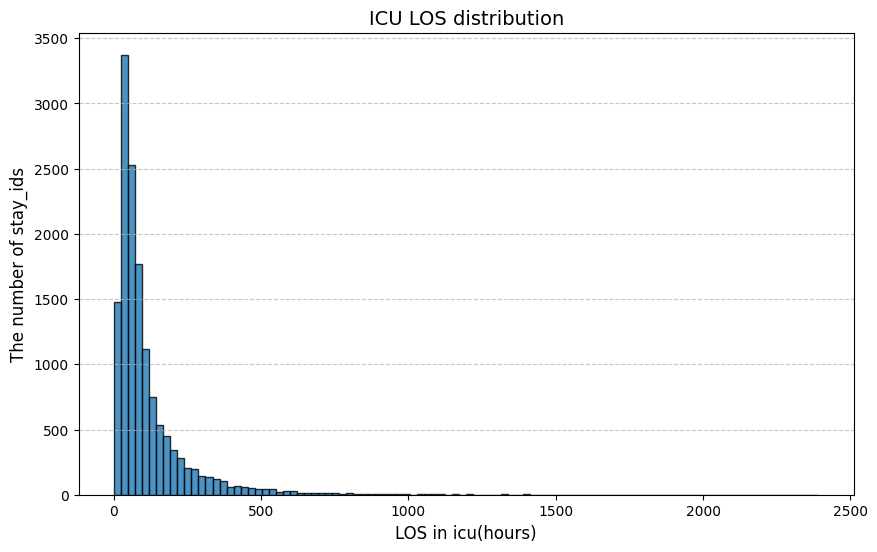

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(updated_df_icustays['los_hours'], bins=100, edgecolor='black', alpha=0.8)
plt.xlabel('LOS in icu(hours)', fontsize=12)
plt.ylabel('The number of stay_ids', fontsize=12)
plt.title('ICU LOS distribution', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("상위 90%: ", np.percentile(updated_df_icustays['los_hours'], 90))
print("상위 95%: ", np.percentile(updated_df_icustays['los_hours'], 95))
print("상위 99%: ", np.percentile(updated_df_icustays['los_hours'], 99))

상위 90%:  253.97847222222222
상위 95%:  362.7211805555556
상위 99%:  695.5868888888888


In [ ]:
print("check: ", len(updated_df_icustays[updated_df_icustays['los_hours'] > 1000]))

check:  37


In [127]:
def create_dynamic_hr_timeslots(icustays_df, freq_minutes=30): 
    time_slots_list = []

    for idx, row in icustays_df.iterrows():
        subject_id = row['subject_id']
        hadm_id = row['hadm_id']
        stay_id = row['stay_id']
        intime = row['intime']
        outtime = row['outtime']

        slot_idx = 0
        slot_start = intime
        delta = pd.Timedelta(minutes=freq_minutes)

        while slot_start < outtime: 
            slot_end = slot_start + delta

            time_slots_list.append({
                'subject_id': subject_id,
                'hadm_id': hadm_id,
                'stay_id': stay_id,
                'slot_idx': slot_idx,
                'slot_start': slot_start,
                'slot_end': slot_end
            })

            slot_idx += 1
            slot_start = slot_end

    time_slots_df = pd.DataFrame(time_slots_list)

    time_slots_df['subject_id'] = time_slots_df['subject_id'].astype(int)
    time_slots_df['hadm_id'] = time_slots_df['hadm_id'].astype(int)
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype(int)

    ######################################## 필터링 ########################################
    orig_stay_count = time_slots_df['stay_id'].nunique()
    orig_row_count = len(time_slots_df)
    
    stay_counts = time_slots_df.groupby('stay_id')['slot_idx'].max() + 1
    
    min_slots = 4                                    # [조건 1] 2시간 이하 제외: 30분 단위이므로 총 슬롯 개수가 4개 미만인 것 제외 (즉, >= 4인 것만 유지)
    max_slots_threshold = stay_counts.quantile(0.95) # [조건 2] 상위 5% 제외: 전체 stay들의 슬롯 개수 중 95분위수

    under_2h_stays = stay_counts[stay_counts < min_slots].index
    top_5_percent_stays = stay_counts[stay_counts > max_slots_threshold].index
    
    valid_stays = stay_counts[(stay_counts >= min_slots) & (stay_counts <= max_slots_threshold)].index    
    filtered_time_slots_df = time_slots_df[time_slots_df['stay_id'].isin(valid_stays)].reset_index(drop=True)

    final_stay_count = filtered_time_slots_df['stay_id'].nunique()
    final_row_count = len(filtered_time_slots_df)

    print("-"*60)
    print(f"❌ 제외된 stay_id 개수:")
    print(f"   - 2시간 이하 제외: {len(under_2h_stays)}개")
    print(f"   - 상위 5% 초과 제외: {len(top_5_percent_stays)}개")
    print("-"*60)
    print(f"✅ 환자 Stay(ICU 입원 건수) 변화: {orig_stay_count}개 -> {final_stay_count}개 (Dropped: {orig_stay_count - final_stay_count}개)")
    print(f"✅ 전체 행(Row) 데이터 개수 변화: {orig_row_count}개 -> {final_row_count}개")
    print("="*60)

    return filtered_time_slots_df

In [128]:
time_slots_df = create_dynamic_hr_timeslots(key_id_icu, freq_minutes=30)

------------------------------------------------------------
❌ 제외된 stay_id 개수:
   - 2시간 이하 제외: 1개
   - 상위 5% 초과 제외: 707개
------------------------------------------------------------
✅ 환자 Stay(ICU 입원 건수) 변화: 14146개 -> 13438개 (Dropped: 708개)
✅ 전체 행(Row) 데이터 개수 변화: 3230388개 -> 2418149개


In [ ]:
# time_slots_df = create_dynamic_hr_timeslots(key_id_icu, freq_minutes=30)

총 제외된 stay_id 개수: 3630개
제외 기준 시간: 약 286.3시간 (약 11.9일)


In [ ]:
# 기존 12144962행
time_slots_df

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 04:50:05
1,10001884,26184834,37510196,1,2131-01-11 04:50:05,2131-01-11 05:20:05
2,10001884,26184834,37510196,2,2131-01-11 05:20:05,2131-01-11 05:50:05
3,10001884,26184834,37510196,3,2131-01-11 05:50:05,2131-01-11 06:20:05
4,10001884,26184834,37510196,4,2131-01-11 06:20:05,2131-01-11 06:50:05
...,...,...,...,...,...,...
2418144,19999987,23865745,36195440,89,2145-11-04 19:29:00,2145-11-04 19:59:00
2418145,19999987,23865745,36195440,90,2145-11-04 19:59:00,2145-11-04 20:29:00
2418146,19999987,23865745,36195440,91,2145-11-04 20:29:00,2145-11-04 20:59:00
2418147,19999987,23865745,36195440,92,2145-11-04 20:59:00,2145-11-04 21:29:00


In [ ]:
# 기존 72587
time_slots_df['stay_id'].nunique()

13438

In [ ]:
# hosp cxr -> icu cxr
intime_df = time_slots_df[time_slots_df['slot_idx'] == 0][['hadm_id', 'stay_id', 'slot_start']]
hosp_cxr_before_icu = hosp_icu_cxr[hosp_icu_cxr['hadm_id'].isin(intime_df['hadm_id'])]
merged_df = hosp_cxr_before_icu.merge(intime_df, on='hadm_id', how='left')

filtered_df = merged_df[
    (merged_df['cxrtime'] >= merged_df['slot_start'] - pd.Timedelta(days=1)) & 
    (merged_df['cxrtime'] < merged_df['slot_start'])
].reset_index(drop=True)

filtered_df['time_diff'] = (filtered_df['slot_start'] - filtered_df['cxrtime']).abs()
filtered_df = filtered_df.sort_values(['hadm_id', 'slot_start', 'time_diff']).reset_index(drop=True)

closest_cxr_df = filtered_df.loc[
    filtered_df.groupby(['hadm_id'])['time_diff'].idxmin()
].reset_index(drop=True)

closest_cxr_df = closest_cxr_df.merge(intime_df, on=['hadm_id', 'slot_start'], how='left')
closest_cxr_df = closest_cxr_df.drop(columns=['stay_id_x', 'stay_id_y'])

In [ ]:
closest_cxr_df

,subject_id,hadm_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,slot_start,time_diff,stay_id
0,15457916,20012254.0,2171-09-04 09:10:51.718,AP,aabb91d8-f7fd81a7-f50ac78f-4aa49ce3-49bec26e,files/p15/p15457916/s54064261,aabb91d8-f7fd81a7-f50ac78f-4aa49ce3-49bec26e.jpg,54064261,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2171-09-04 16:59:56,0 days 07:49:04.282000,34250019
1,19210871,20020562.0,2150-08-19 08:38:28.468,AP,0240b411-8ab0e647-bbd00587-ac5ed4cc-cacf2c41,files/p19/p19210871/s52238602,0240b411-8ab0e647-bbd00587-ac5ed4cc-cacf2c41.jpg,52238602,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,2150-08-19 10:01:30,0 days 01:23:01.532000,30253505
2,18549459,20021612.0,2162-05-06 19:22:25.406,AP,f0b0b20d-413d3332-3a3ee847-b8a542ca-d5430d7b,files/p18/p18549459/s50260240,f0b0b20d-413d3332-3a3ee847-b8a542ca-d5430d7b.jpg,50260240,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2162-05-06 19:23:50,0 days 00:01:24.594000,34145253
3,11300581,20022952.0,2120-01-24 22:56:55.046,AP,5e3d3f3a-d432079d-704c49a8-c96bea98-3922cb58,files/p11/p11300581/s59864479,5e3d3f3a-d432079d-704c49a8-c96bea98-3922cb58.jpg,59864479,1.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,0.0,2120-01-25 02:34:14,0 days 03:37:18.954000,39724160
4,14362539,20023225.0,2140-06-30 13:17:05.125,AP,c4c18d33-6d4d1d67-b114fee5-17d16446-8e4239f9,files/p14/p14362539/s55613271,c4c18d33-6d4d1d67-b114fee5-17d16446-8e4239f9.jpg,55613271,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2140-06-30 15:13:00,0 days 01:55:54.875000,35035530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2423,18692094,29967655.0,2177-10-19 22:24:46.218,AP,5913c585-34d7c3f4-925e08dc-31b95c3e-51ad7d37,files/p18/p18692094/s59297679,5913c585-34d7c3f4-925e08dc-31b95c3e-51ad7d37.jpg,59297679,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,2177-10-19 22:49:00,0 days 00:24:13.782000,35646928
2424,17854225,29973313.0,2155-04-18 22:42:04.593,AP,6064acca-69c0399a-fc413004-7f561672-54c21f46,files/p17/p17854225/s59822995,6064acca-69c0399a-fc413004-7f561672-54c21f46.jpg,59822995,NaN,NaN,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2155-04-18 23:17:43,0 days 00:35:38.407000,32878949
2425,17646651,29988947.0,2175-09-02 22:47:29.546,AP,65092dc6-e28f8832-f5759cfd-da7ed52b-1216368a,files/p17/p17646651/s51866138,65092dc6-e28f8832-f5759cfd-da7ed52b-1216368a.jpg,51866138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2175-09-02 23:29:07,0 days 00:41:37.454000,38518978
2426,17396346,29990184.0,2187-06-19 10:33:24.171,AP,cf843573-ae7cd8aa-c637c215-2d2fa112-c95d2574,files/p17/p17396346/s51828119,cf843573-ae7cd8aa-c637c215-2d2fa112-c95d2574.jpg,51828119,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2187-06-19 16:18:25,0 days 05:45:00.829000,38079136


<!-- --- -->

<!-- ## 4.1 Procedure events -->

## Procedure events

In [ ]:
# # ekg
# proc_itemid = [225402, 225794]

In [ ]:
# proc_list = df_ditems[df_ditems['itemid'].isin(proc_itemid)].reset_index(drop=True)
# proc_list

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,225402,EKG,EKG,procedureevents,4-Procedures,None,Processes,NaN,NaN
1,225794,Non-invasive Ventilation,Non-invasive Ventilation,procedureevents,2-Ventilation,None,Processes,NaN,NaN


In [ ]:
# def resampling_procedure(procedureevents, time_slots_df):

#     """
#     Procedure event를 proc_itemid를 한정하여 resampling함.
#     이때 procedure이 시행되었는지 여부를 0, 1로 라벨링함.
#     """

#     procedureevents = procedureevents[procedureevents['itemid'].isin(proc_itemid)]

#     procedureevents = procedureevents.drop(columns=['valueuom', 'patientweight'])
#     procedureevents = procedureevents.sort_values(by=['stay_id', 'itemid', 'starttime']).reset_index(drop=True)

#     binary_results = []

#     # Binary 처리
#     for idx, row in tqdm(procedureevents.iterrows(), total=len(procedureevents), desc="Processing procedureevents"):
#         hadm = row['hadm_id']
#         stay = row['stay_id']
#         start_time = row['starttime']
#         end_time = row['endtime']
#         itemid = row['itemid']

#         patient_slots = time_slots_df[time_slots_df['stay_id'] == stay].copy()

#         overlapping = patient_slots[
#             (patient_slots['slot_start'] <= end_time) &
#             (patient_slots['slot_end'] > start_time)]
        
#         if overlapping.empty:
#             continue

#         for idx, slotrow in overlapping.iterrows(): 
#             binary_results.append({
#                 'hadm_id': hadm,
#                 'stay_id': stay,
#                 'itemid': itemid,
#                 'hour_slot': slotrow['hour_slot'],
#                 'slot_start': slotrow['slot_start'],
#                 'procedure_flag': 1
#             })

#     binary_results = pd.DataFrame(binary_results).drop_duplicates()
#     expanded_results = []

#     for itemid in tqdm(proc_itemid, total = len(proc_itemid), desc = "Processing procedureevents"):
#         item_slots = time_slots_df.copy()
#         item_slots['itemid'] = itemid
#         item_slots['procedure_flag'] = 0

#         item_data = binary_results[binary_results['itemid']==itemid]
        
#         if not item_data.empty:
#             item_slots = pd.merge(item_slots, item_data[['stay_id', 'hour_slot', 'procedure_flag']], how='left', on=['stay_id', 'hour_slot'])
#             item_slots['procedure_flag'] = item_slots['procedure_flag_y'].fillna(item_slots['procedure_flag_x']).astype(int)
#             item_slots = item_slots.drop(columns=['procedure_flag_x', 'procedure_flag_y'])
#         expanded_results.append(item_slots)

#     processed_df = pd.concat(expanded_results, ignore_index=True)
#     return processed_df

In [ ]:
# sequential_df_proc = resampling_procedure(df_proc, time_slots_df)
# sequential_df_proc

Processing procedureevents:   0%|          | 0/12011 [00:00<?, ?it/s]

Processing procedureevents:   0%|          | 0/2 [00:00<?, ?it/s]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,procedure_flag
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,225402,0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,225402,0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,225402,1
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,225402,1
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,225402,0
...,...,...,...,...,...,...,...
3237537,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,225794,0
3237538,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,225794,0
3237539,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,225794,0
3237540,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,225794,0


In [ ]:
# df_proc[(df_proc['itemid']==225794) & (df_proc['stay_id']==37510196)]

,subject_id,hadm_id,stay_id,starttime,endtime,itemid,value,valueuom,patientweight
0,10001884,26184834,37510196,2131-01-12 21:30:00,2131-01-13 04:00:00,225794,390.0,min,65.0


In [ ]:
# sequential_df_proc[(sequential_df_proc['itemid']==225794) & (sequential_df_proc['stay_id']==37510196)].iloc[35:50, :]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,procedure_flag
1618806,26184834,37510196,35,2131-01-12 15:20:05,2131-01-12 16:20:05,225794,0
1618807,26184834,37510196,36,2131-01-12 16:20:05,2131-01-12 17:20:05,225794,0
1618808,26184834,37510196,37,2131-01-12 17:20:05,2131-01-12 18:20:05,225794,0
1618809,26184834,37510196,38,2131-01-12 18:20:05,2131-01-12 19:20:05,225794,0
1618810,26184834,37510196,39,2131-01-12 19:20:05,2131-01-12 20:20:05,225794,0
1618811,26184834,37510196,40,2131-01-12 20:20:05,2131-01-12 21:20:05,225794,0
1618812,26184834,37510196,41,2131-01-12 21:20:05,2131-01-12 22:20:05,225794,1
1618813,26184834,37510196,42,2131-01-12 22:20:05,2131-01-12 23:20:05,225794,1
1618814,26184834,37510196,43,2131-01-12 23:20:05,2131-01-13 00:20:05,225794,1
1618815,26184834,37510196,44,2131-01-13 00:20:05,2131-01-13 01:20:05,225794,1


In [ ]:
# sequential_df_proc['procedure_flag'].value_counts()

procedure_flag
0    3209523
1      28019
Name: count, dtype: int64

In [ ]:
# sequential_df_proc.to_feather(store_dir + '/processed/sequential_df_proc.ftr')

<!-- ## 4.2 Medication(Inputevents) -->

<!-- - starttime과 endtime이 동일한 Bolus 확인해보기 -->

In [ ]:
# # furosemide 250/50 -> furosemide로 통일
# df_input.loc[df_input['itemid']==228340, 'itemid'] = 221794

In [ ]:
# # medication에서는 albumin (220862) 삭제, bumetanide, angiotensin도 삭제 -> chartevent에서 활용함
# med_itemid = [221794, 221906, 221662, 221653, 221749, 221986, 222051, 222056, 225168, 225974] 

In [ ]:
# med_list = df_ditems[df_ditems['itemid'].isin(med_itemid)].reset_index(drop=True)
# med_list

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,221653,Dobutamine,Dobutamine,inputevents,Medications,mg,Solution,NaN,NaN
1,221662,Dopamine,Dopamine,inputevents,Medications,mg,Solution,NaN,NaN
2,221749,Phenylephrine,Phenylephrine,inputevents,Medications,mg,Solution,NaN,NaN
3,221794,Furosemide (Lasix),Furosemide (Lasix),inputevents,Medications,mg,Solution,NaN,NaN
4,221906,Norepinephrine,Norepinephrine,inputevents,Medications,mg,Solution,NaN,NaN
5,221986,Milrinone,Milrinone,inputevents,Medications,mg,Solution,NaN,NaN
6,222051,Nitroprusside,Nitroprusside,inputevents,Medications,mg,Solution,NaN,NaN
7,222056,Nitroglycerin,Nitroglycerin,inputevents,Medications,mg,Solution,NaN,NaN
8,225168,Packed Red Blood Cells,PRBC's,inputevents,Blood Products/Colloids,mL,Solution,NaN,NaN
9,225974,Metoprolol,Metoprolol,inputevents,Medications,mg,Solution,NaN,NaN


In [ ]:
# # inputevents resampling
# def resampling_input(inputevents, time_slots_df): 
#     """
#     input event를 proc_itemid를 한정하여 resampling함.
#     투여량을 시간에 비례하여 분할하여 같은 itemid끼리는 합산하여 시간당 투여량을 계산함.
#     """

#     inputevents = inputevents[inputevents['itemid'].isin(med_itemid)]
#     inputevents = inputevents.drop(columns=['rate', 'rateuom', 'patientweight'])
#     inputevents = inputevents.sort_values(by=['stay_id', 'itemid', 'starttime']).reset_index(drop=True)

#     expanded_results = []

#     for itemid in tqdm(med_itemid, total=len(med_itemid), desc="Processing inputevents"): 
#         item_slots = time_slots_df.copy()
#         item_slots['itemid'] = itemid
#         item_slots['input_amount'] = np.nan

#         item_data = inputevents[inputevents['itemid'] == itemid]

#         records = []

#         for _, row in item_data.iterrows():
#             stay = row['stay_id']
#             start_time = row['starttime']
#             end_time = row['endtime']
#             amount = row['amount']

#             patient_slots = time_slots_df[time_slots_df['stay_id']==stay].copy()
#             overlapping = patient_slots[(patient_slots['slot_start'] <= end_time) & (patient_slots['slot_end'] > start_time)]
            
#             if overlapping.empty:
#                 continue
            
#             total_hours = (end_time - start_time).total_seconds() / 3600.0

#             if total_hours < 0: 
#                 continue

#             for _, slotrow in overlapping.iterrows(): 
#                 if total_hours == 0:
#                     # Bolus
#                     amount_per_slot = amount

#                 else: 
#                     # Continuous infusion
#                     overlap_start = max(start_time, slotrow['slot_start'])
#                     overlap_end = min(end_time, slotrow['slot_end'])

#                     hours_in_slot = (overlap_end - overlap_start).total_seconds() / 3600.0
#                     hours_in_slot = max(0, hours_in_slot)

#                     amount_per_slot = amount * (hours_in_slot / total_hours)

#                 records.append({
#                     'stay_id': stay,
#                     'hour_slot': slotrow['hour_slot'],
#                     'input_amount': amount_per_slot
#                 })

#         if records:
#             item_data_df = pd.DataFrame(records)
#             grouped_item = item_data_df.groupby(['stay_id', 'hour_slot'], as_index=False)['input_amount'].sum()
    
#             item_slots = pd.merge(item_slots, grouped_item, how='left', on=['stay_id', 'hour_slot'])

#             item_slots['input_amount'] = item_slots['input_amount_y'].combine_first(item_slots['input_amount_x'])
#             item_slots = item_slots.drop(columns=['input_amount_x', 'input_amount_y'])

#         expanded_results.append(item_slots)

#     processed_df = pd.concat(expanded_results, ignore_index=True)
#     return processed_df

In [ ]:
# sequential_df_med = resampling_input(df_input, time_slots_df)
# sequential_df_med

Processing inputevents:   0%|          | 0/10 [00:00<?, ?it/s]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,input_amount
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,221794,NaN
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,221794,NaN
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,221794,NaN
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,221794,NaN
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,221794,NaN
...,...,...,...,...,...,...,...
16187705,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,225974,NaN
16187706,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,225974,NaN
16187707,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,225974,NaN
16187708,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,225974,NaN


In [ ]:
# sequential_df_med.to_feather(store_dir + '/processed/sequential_df_med.ftr')

In [ ]:
fluid_only_dict = {
    'fluid_alb': my_query_dict['fluid_alb'],
    'fluid_cyst': my_query_dict['fluid_cyst']
}

def resampling_fluid(inputevents, time_slots_df, fluid_dict): 
    """
    fluid_dict (예: my_query_dict)에 정의된 카테고리(fluid_alb, fluid_cyst)를 기준으로
    해당 카테고리에 속하는 여러 itemid의 투여량을 묶어서 시간대별로 합산함.
    """
    
    item_to_category = {}
    for category, item_ids in fluid_dict.items():
        for itemid in item_ids:
            item_to_category[itemid] = category
            
    # 매핑된 itemid에 해당하는 데이터만 필터링
    fluid_events = inputevents[inputevents['itemid'].isin(item_to_category.keys())].copy()
    fluid_events['fluid_category'] = fluid_events['itemid'].map(item_to_category)

    fluid_events = fluid_events[fluid_events['amount'] > 0]
    fluid_events = fluid_events.drop(columns=['rate', 'rateuom', 'patientweight'], errors='ignore')
    fluid_events = fluid_events.sort_values(by=['stay_id', 'fluid_category', 'starttime']).reset_index(drop=True)

    expanded_results = []
    categories = list(fluid_dict.keys())
    chunk_size = 3000
    
    for cat in tqdm(categories, total=len(categories), desc="Processing fluid categories"): 
        cat_data = fluid_events[fluid_events['fluid_category'] == cat]

        unique_stays = cat_data['stay_id'].unique()
        all_grouped_chunks = []

        for i in tqdm(range(0, len(unique_stays), chunk_size), desc=f"Chunking {cat}", leave=False):
            chunk_stays = unique_stays[i : i + chunk_size]

            cat_chunk = cat_data[cat_data['stay_id'].isin(chunk_stays)]
            slot_chunk = time_slots_df[time_slots_df['stay_id'].isin(chunk_stays)]

            merged = pd.merge(cat_chunk, slot_chunk, on='stay_id', how='inner')
                
            # 시간이 겹치는 구간만 남기고 필터링
            mask = (merged['slot_start'] <= merged['endtime']) & (merged['slot_end'] >= merged['starttime'])
            valid = merged[mask].copy()
            del merged
        
            # 각 투여 기록의 총 투여 시간 계산
            valid['total_hours'] = (valid['endtime'] - valid['starttime']).dt.total_seconds() / 3600.0
            valid = valid[valid['total_hours'] >= 0]
        
            # 겹치는 시간 계산
            overlap_start = np.maximum(valid['starttime'], valid['slot_start'])
            overlap_end = np.minimum(valid['endtime'], valid['slot_end'])
        
            valid['hours_in_slot'] = (overlap_end - overlap_start).dt.total_seconds() / 3600.0
            valid['hours_in_slot'] = valid['hours_in_slot'].clip(lower=0) # 음수 방지
        
            # 투여량 분할 계산
            is_bolus = valid['total_hours'] == 0
            is_bolus_in_slot = is_bolus & (valid['starttime'] >= valid['slot_start']) & (valid['starttime'] < valid['slot_end'])

            valid['amount_per_slot'] = np.where(
                is_bolus,
                np.where(is_bolus_in_slot, valid['amount'], 0),
                valid['amount'] * (valid['hours_in_slot'] / valid['total_hours']) # Continuous
            )

            grouped_chunk = valid.groupby(['stay_id', 'slot_idx'], as_index=False)['amount_per_slot'].sum()
            all_grouped_chunks.append(grouped_chunk)

            del valid, cat_chunk, slot_chunk

        if all_grouped_chunks:
            grouped = pd.concat(all_grouped_chunks, ignore_index=True)
        else:
            grouped = pd.DataFrame(columns=['stay_id', 'slot_idx', 'amount_per_slot'])
            
        grouped.rename(columns={'amount_per_slot': 'input_amount'}, inplace=True)
        
        # 최종 병합
        item_slots = time_slots_df.copy()
        item_slots['fluid_category'] = cat
        item_slots = pd.merge(item_slots, grouped, how='left', on=['stay_id', 'slot_idx'])
        item_slots['input_amount'] = item_slots['input_amount'].fillna(0)

        expanded_results.append(item_slots)

    processed_df = pd.concat(expanded_results, ignore_index=True)
    return processed_df

In [ ]:
sequential_df_fluid = resampling_fluid(df_input, time_slots_df, fluid_only_dict)
sequential_df_fluid

Processing fluid categories:   0%|          | 0/2 [00:00<?, ?it/s]

Chunking fluid_alb:   0%|          | 0/1 [00:00<?, ?it/s]

Chunking fluid_cyst:   0%|          | 0/5 [00:00<?, ?it/s]

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,fluid_category,input_amount
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 04:50:05,fluid_alb,0.0
1,10001884,26184834,37510196,1,2131-01-11 04:50:05,2131-01-11 05:20:05,fluid_alb,0.0
2,10001884,26184834,37510196,2,2131-01-11 05:20:05,2131-01-11 05:50:05,fluid_alb,0.0
3,10001884,26184834,37510196,3,2131-01-11 05:50:05,2131-01-11 06:20:05,fluid_alb,0.0
4,10001884,26184834,37510196,4,2131-01-11 06:20:05,2131-01-11 06:50:05,fluid_alb,0.0
...,...,...,...,...,...,...,...,...
4836293,19999987,23865745,36195440,89,2145-11-04 19:29:00,2145-11-04 19:59:00,fluid_cyst,0.0
4836294,19999987,23865745,36195440,90,2145-11-04 19:59:00,2145-11-04 20:29:00,fluid_cyst,0.0
4836295,19999987,23865745,36195440,91,2145-11-04 20:29:00,2145-11-04 20:59:00,fluid_cyst,201.2
4836296,19999987,23865745,36195440,92,2145-11-04 20:59:00,2145-11-04 21:29:00,fluid_cyst,0.0


In [ ]:
sequential_df_fluid.to_feather(store_dir + 'sequential_df_fluid.ftr')

<!-- - sbp dbp부터 -->

## Blood Pressure

In [ ]:
key_ids = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]
df_bp = key_ids.merge(df_sbpdbp, how='left', on=['subject_id', 'hadm_id', 'stay_id'])
df_bp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp
0,10001884,26184834.0,37510196.0,2131-01-11 04:25:00,180.0,12.0
1,10001884,26184834.0,37510196.0,2131-01-11 05:01:00,167.0,49.0
2,10001884,26184834.0,37510196.0,2131-01-11 06:01:00,102.0,63.0
3,10001884,26184834.0,37510196.0,2131-01-11 06:47:00,110.0,76.0
4,10001884,26184834.0,37510196.0,2131-01-11 07:01:00,93.0,62.0
...,...,...,...,...,...,...
996277,19999987,23865745.0,36195440.0,2145-11-04 09:00:00,117.0,52.0
996278,19999987,23865745.0,36195440.0,2145-11-04 13:48:00,121.0,72.0
996279,19999987,23865745.0,36195440.0,2145-11-04 16:53:00,152.0,92.0
996280,19999987,23865745.0,36195440.0,2145-11-04 19:31:00,163.0,120.0


In [ ]:
df_bp.isnull().sum()

subject_id      0
hadm_id         0
stay_id         0
charttime     998
sbp           998
dbp           998
dtype: int64

In [ ]:
# 혈압을 아예 측정하지 않은 stay_id가 998행 존재함.
df_bp[df_bp['charttime'].isna()]

,subject_id,hadm_id,stay_id,charttime,sbp,dbp
394,10002428,28662225.0,33987268.0,NaT,NaN,NaN
809,10003400,23559586.0,34577403.0,NaT,NaN,NaN
1857,10013569,27993048.0,38857852.0,NaT,NaN,NaN
3344,10020740,23831430.0,31077365.0,NaT,NaN,NaN
3345,10020740,23831430.0,35026312.0,NaT,NaN,NaN
...,...,...,...,...,...,...
992377,19965802,21104872.0,33646490.0,NaT,NaN,NaN
992629,19966789,24136386.0,32318562.0,NaT,NaN,NaN
994040,19986715,28333468.0,30045509.0,NaT,NaN,NaN
994658,19992885,20352341.0,35180845.0,NaT,NaN,NaN


In [ ]:
df_bp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp
0,10001884,26184834.0,37510196.0,2131-01-11 04:25:00,180.0,12.0
1,10001884,26184834.0,37510196.0,2131-01-11 05:01:00,167.0,49.0
2,10001884,26184834.0,37510196.0,2131-01-11 06:01:00,102.0,63.0
3,10001884,26184834.0,37510196.0,2131-01-11 06:47:00,110.0,76.0
4,10001884,26184834.0,37510196.0,2131-01-11 07:01:00,93.0,62.0
...,...,...,...,...,...,...
996277,19999987,23865745.0,36195440.0,2145-11-04 09:00:00,117.0,52.0
996278,19999987,23865745.0,36195440.0,2145-11-04 13:48:00,121.0,72.0
996279,19999987,23865745.0,36195440.0,2145-11-04 16:53:00,152.0,92.0
996280,19999987,23865745.0,36195440.0,2145-11-04 19:31:00,163.0,120.0


In [ ]:
def resampling_bp(df_bp, time_slots_df):
    df_bp = df_bp.copy()

    df_bp = df_bp.dropna(subset=['stay_id', 'charttime'])

    df_bp['stay_id'] = df_bp['stay_id'].astype('int')
    df_bp['charttime'] = pd.to_datetime(df_bp['charttime'])

    time_slots = time_slots_df.copy()
    time_slots['stay_id'] = time_slots['stay_id'].astype('int')
    time_slots['slot_start'] = pd.to_datetime(time_slots['slot_start'])
    
    df_bp = df_bp.sort_values(by=['charttime']).reset_index(drop=True)
    time_slots = time_slots.sort_values(by=['slot_start']).reset_index(drop=True)

    # 혈압 측정 시간(charttime)을 기준으로 가장 가까운 과거의 타임슬롯(slot_start)에 매핑
    merged = pd.merge_asof(
        df_bp,
        time_slots[['stay_id', 'slot_idx', 'slot_start', 'slot_end']],
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward'
    )

    # 매핑된 데이터가 실제 해당 30분 슬롯 구간 안에 들어오는지 한 번 더 검증
    merged = merged.dropna(subset=['slot_start']) # 타임슬롯 이전의 과거 데이터 제외
    mask = (merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])
    valid = merged[mask].copy()

    # 동일한 환자(stay_id)의 동일한 30분 슬롯(slot_idx) 내 측정값 평균 계산
    grouped = valid.groupby(['stay_id', 'slot_idx'], as_index=False).agg(
        sbp_mean=('sbp', 'mean'),
        dbp_mean=('dbp', 'mean')
    )

    # 원본 time_slots_df(완벽한 30분 격자)에 최종 Left Join
    # 혈압 측정이 없었던 30분 구간은 자동으로 NaN이 됩니다.
    final_result = pd.merge(
        time_slots,
        grouped,
        on=['stay_id', 'slot_idx'],
        how='left'
    )

    return final_result.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)

In [ ]:
df_resampled_bp = resampling_bp(df_bp, time_slots_df)
sequential_df_bp = df_resampled_bp.rename(columns={'sbp_mean':'sbp', 'dbp_mean':'dbp'})
sequential_df_bp

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,sbp,dbp
0,12207593,22795209,30000646,0,2194-04-29 01:39:22,2194-04-29 02:09:22,109.0,65.5
1,12207593,22795209,30000646,1,2194-04-29 02:09:22,2194-04-29 02:39:22,NaN,NaN
2,12207593,22795209,30000646,2,2194-04-29 02:39:22,2194-04-29 03:09:22,97.0,58.0
3,12207593,22795209,30000646,3,2194-04-29 03:09:22,2194-04-29 03:39:22,NaN,NaN
4,12207593,22795209,30000646,4,2194-04-29 03:39:22,2194-04-29 04:09:22,98.0,57.0
...,...,...,...,...,...,...,...,...
2418144,19046950,24352151,39998622,427,2135-02-20 15:43:55,2135-02-20 16:13:55,127.0,82.0
2418145,19046950,24352151,39998622,428,2135-02-20 16:13:55,2135-02-20 16:43:55,NaN,NaN
2418146,19046950,24352151,39998622,429,2135-02-20 16:43:55,2135-02-20 17:13:55,120.0,71.0
2418147,19046950,24352151,39998622,430,2135-02-20 17:13:55,2135-02-20 17:43:55,NaN,NaN


In [ ]:
sequential_df_bp.to_feather(store_dir + 'sequential_df_bp.ftr')

<!-- ## 4.3 Chart events -->

In [ ]:
itemid_map = {
    50862:227456, 52022:227456, 53085:227456, 53138:227456,         # albumin
    50983:220645, 52623:220645, 50824:220645, 52455:220645,         # sodium
    51006:225624, 52647:225624,                                     # bun
    50868:227073, 52500:227073,                                     # anion gap
    51003:227429,                                                   # troponin-t
    50971:227442, 52610:227442, 50822:227442, 52452:227442,         # potassium
    50816:223835,                                                   # fio2
    50911:227445,                                                   # CK-MB
    50912:220615, 52546:220615, 52024:220615,                       # Creatinine
    51300:220546, 51301:220546, 51755:220546, 51756:220546,         # WBC
    50813:225668, 52442:225668,                                     # Lactate        
}

In [ ]:
target_itemids = list(itemid_map.keys()) # key로 뽑아서,
print(target_itemids)

[50862, 52022, 53085, 53138, 50983, 52623, 50824, 52455, 51006, 52647, 50868, 52500, 51003, 50971, 52610, 50822, 52452, 50816, 50911, 50912, 52546, 52024, 51300, 51301, 51755, 51756, 50813, 52442]


In [ ]:
filtered_df = df_dlabitems[df_dlabitems['itemid'].isin(itemid_map.keys())]
filtered_df

,itemid,label,fluid,category
11,50813,Lactate,Blood,Blood Gas
14,50816,Oxygen,Blood,Blood Gas
20,50822,"Potassium, Whole Blood",Blood,Blood Gas
22,50824,"Sodium, Whole Blood",Blood,Blood Gas
60,50862,Albumin,Blood,Chemistry
66,50868,Anion Gap,Blood,Chemistry
109,50911,"Creatine Kinase, MB Isoenzyme",Blood,Chemistry
110,50912,Creatinine,Blood,Chemistry
168,50971,Potassium,Blood,Chemistry
180,50983,Sodium,Blood,Chemistry


In [ ]:
bakcup_df_lab = df_lab.copy()

In [ ]:
def get_ward_lab_before_icu_admission(df_lab, time_slots_df, itemid_map):
    valid_itemids = set(itemid_map.keys())
    df_lab = df_lab[df_lab['itemid'].isin(valid_itemids)]

    icu_start_df = time_slots_df[time_slots_df['slot_idx'] == 0][['stay_id', 'hadm_id', 'slot_start']]
    df_lab = df_lab.merge(icu_start_df, on='hadm_id', how='inner')
    
    df_lab = df_lab[
        (df_lab['charttime'] >= df_lab['slot_start'] - pd.Timedelta(hours=24)) &
        (df_lab['charttime'] < df_lab['slot_start'])
    ].copy()
    
    # itemid 변환 (Lab -> ICU)
    df_lab['itemid'] = df_lab['itemid'].map(itemid_map)
    df_lab['time_diff'] = (df_lab['slot_start'] - df_lab['charttime']).abs()
    
    # ICU T=0 slot으로 할당할 값 남기기
    closest = df_lab.loc[df_lab.groupby(['stay_id', 'itemid'])['time_diff'].idxmin()].copy()
    closest['slot_idx'] = 0
    return closest[['stay_id', 'itemid', 'slot_idx', 'slot_start', 'valuenum']].rename(columns={'valuenum': 'value'})

In [ ]:
df_ward_T0 = get_ward_lab_before_icu_admission(df_lab, time_slots_df, itemid_map)
df_ward_T0

,stay_id,itemid,slot_idx,slot_start,value
348100,30000646,220546,0,2194-04-29 01:39:22,8.3
348096,30000646,220615,0,2194-04-29 01:39:22,1.0
348098,30000646,220645,0,2194-04-29 01:39:22,137.0
348099,30000646,225624,0,2194-04-29 01:39:22,11.0
348095,30000646,227073,0,2194-04-29 01:39:22,12.0
...,...,...,...,...,...
1352819,39998622,220615,0,2135-02-11 18:13:55,1.0
1352823,39998622,220645,0,2135-02-11 18:13:55,138.0
1352825,39998622,225624,0,2135-02-11 18:13:55,16.0
1352817,39998622,227073,0,2135-02-11 18:13:55,17.0


In [ ]:
df_ward_T0['itemid'].unique()

array([220546, 220615, 220645, 225624, 227073, 227442, 225668, 227456,
       223835, 227429, 227445])

In [ ]:
def assign_stayid_to_lab(df_lab, time_slots_df, itemid_map):
    valid_itemids = set(itemid_map.keys())
    df_lab = df_lab[df_lab['itemid'].isin(valid_itemids)].copy()

    icu_min_time = time_slots_df['slot_start'].min()
    df_lab = df_lab[df_lab['charttime'] >= icu_min_time].copy()

    icu_stay_ranges = time_slots_df.groupby(['stay_id', 'hadm_id'], as_index=False).agg(
        intime=('slot_start', 'min'),
        outtime=('slot_end', 'max') # <- 30분 단위에 맞게 정확히 매핑됨
    )

    merged_lab = pd.merge(df_lab, icu_stay_ranges, on='hadm_id', how='inner')

    mask = (merged_lab['charttime'] >= merged_lab['intime']) & (merged_lab['charttime'] < merged_lab['outtime'])
    valid_lab = merged_lab[mask].copy()

    valid_lab = valid_lab.drop(columns=['intime', 'outtime'])

    return valid_lab

In [ ]:
stayid_with_lab = assign_stayid_to_lab(df_lab, time_slots_df, itemid_map)

In [ ]:
def get_ward_lab_within_icu_stay(df_lab, time_slots_df, itemid_map):
    df_lab = df_lab.copy()
    df_lab = df_lab.dropna(subset=['stay_id', 'charttime'])
    
    df_lab = df_lab[df_lab['itemid'].isin(itemid_map.keys())].copy()
    df_lab['itemid'] = df_lab['itemid'].map(itemid_map) # mapping

    time_slots_df = time_slots_df.copy()

    df_lab['stay_id'] = df_lab['stay_id'].astype('int')
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype('int')

    df_lab_sorted = df_lab.sort_values('charttime').reset_index(drop=True)
    slots_sorted = time_slots_df.sort_values('slot_start').reset_index(drop=True)

    # 병동 lab을 ICU 시간 슬롯에 할당
    merged = pd.merge_asof(
        df_lab_sorted,
        slots_sorted,
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward' # 과거 시점만 허용함.
    )

    merged = merged.dropna(subset=['slot_start'])
    merged = merged[(merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])]

    grouped = merged.groupby(['stay_id', 'itemid', 'slot_idx', 'slot_start']) \
                    .agg(value=('valuenum', 'mean')) \
                    .reset_index()
                    
    return grouped

In [ ]:
labs_during_icu = get_ward_lab_within_icu_stay(stayid_with_lab, time_slots_df, itemid_map)
labs_during_icu

,stay_id,itemid,slot_idx,slot_start,value
0,30000646,220546,1,2194-04-29 02:09:22,8.5
1,30000646,220546,8,2194-04-29 05:39:22,10.6
2,30000646,220546,35,2194-04-29 19:09:22,7.9
3,30000646,220546,55,2194-04-30 05:09:22,7.2
4,30000646,220546,110,2194-05-01 08:39:22,8.8
...,...,...,...,...,...
630986,39998622,227442,379,2135-02-19 15:43:55,3.7
630987,39998622,227442,402,2135-02-20 03:13:55,4.2
630988,39998622,227442,424,2135-02-20 14:13:55,3.9
630989,39998622,227456,64,2135-02-13 02:13:55,2.9


In [ ]:
# temperature 단위 변환은 완료했으니 하나로 통일
df_chart['itemid'] = df_chart['itemid'].replace({223762:223761})

# NBPs, NBPd는 별도로 처리하기로 되었으므로 제외함.
chart_itemid = [220045, 220277, 220210, 227429, 227446, 225624, 227073, 223761, 220645, 227442, 223835, 227456, 227445, 220615, 220546, 225668] # New

In [ ]:
chart_list = df_ditems[df_ditems['itemid'].isin(chart_itemid)].reset_index(drop=True)
chart_list

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
1,220210,Respiratory Rate,RR,chartevents,Respiratory,insp/min,Numeric,NaN,NaN
2,220277,O2 saturation pulseoxymetry,SpO2,chartevents,Respiratory,%,Numeric,NaN,NaN
3,220546,WBC,WBC,chartevents,Labs,None,Numeric,NaN,NaN
4,220615,Creatinine (serum),Creatinine (serum),chartevents,Labs,None,Numeric,NaN,NaN
5,220645,Sodium (serum),Sodium (serum),chartevents,Labs,None,Numeric,NaN,NaN
6,223761,Temperature Fahrenheit,Temperature F,chartevents,Routine Vital Signs,°F,Numeric,NaN,NaN
7,223835,Inspired O2 Fraction,FiO2,chartevents,Respiratory,None,Numeric,NaN,NaN
8,225624,BUN,BUN,chartevents,Labs,None,Numeric,NaN,NaN
9,225668,Lactic Acid,Lactic Acid,chartevents,Labs,None,Numeric,NaN,NaN


In [ ]:
def resampling_chart(chartevents, time_slots_df, chart_itemid):
    chartevents = chartevents.dropna(subset=['stay_id', 'charttime']).copy()
    chartevents = chartevents[chartevents['itemid'].isin(chart_itemid)]
    chartevents['stay_id'] = chartevents['stay_id'].astype('int')

    time_slots_df = time_slots_df.copy()
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype('int')

    chartevents_sorted = chartevents.sort_values('charttime').reset_index(drop=True)
    slots_sorted = time_slots_df.sort_values('slot_start').reset_index(drop=True)

    merged = pd.merge_asof(
        chartevents_sorted,
        slots_sorted,
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward'
    )

    merged = merged.dropna(subset=['slot_start'])
    merged = merged[(merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])]

    grouped = (
        merged.groupby(['stay_id', 'itemid', 'slot_idx', 'slot_start'], as_index=False)
        .agg(
            value_mean=('valuenum', 'mean'),
            value_max=('valuenum', 'max')
        )
    )

    # 체온(223761)은 최댓값, 나머지는 평균값 사용
    grouped['value'] = np.where(
        grouped['itemid'] == 223761, 
        grouped['value_max'], 
        grouped['value_mean']
    )

    grouped = grouped.drop(columns=['value_mean', 'value_max'])

    stay_slots = time_slots_df[['stay_id', 'slot_idx', 'slot_start']].drop_duplicates()
    items_df = pd.DataFrame({'itemid': chart_itemid})
    full_slots = stay_slots.merge(items_df, how='cross')

    final_result = pd.merge(
        full_slots, grouped,
        on=['stay_id', 'slot_idx', 'slot_start', 'itemid'],
        how='left'
    )

    return final_result.sort_values(['stay_id', 'itemid', 'slot_start']).reset_index(drop=True)

In [ ]:
sequential_df_chart = resampling_chart(df_chart, time_slots_df, chart_itemid)

In [ ]:
check = sequential_df_chart[sequential_df_chart['itemid']==227446]
check['value'].max() # 50976

55646.0

In [ ]:
sequential_df_chart.to_feather(store_dir + 'sequential_df_chart.ftr')

<!-- | 이름          | 내용                                                                 | 생성 방법                        |
|---------------|----------------------------------------------------------------------|----------------------------------|
| `sequential_df_chart`    | ICU stay 중 chart events를 `slot_start` 기준으로 리샘플링한 시계열      | `resampling_chart()`             |
| `df_ward_T0`  | ICU 입실 전 24시간 내 병동 lab 중 가장 최근값을 T=0 slot에 할당         | `get_ward_lab_before_icu_admission()` |
| `df_ward_icu` | ICU stay 중 charttime이 ICU 체류 구간에 포함되는 병동 lab 값을 각 slot에 할당 | `get_ward_lab_within_icu_stay()` | -->

<!-- - NTproBNP는 잠시 제외함. -->

In [ ]:
# df_ntprobnp_during_icu = labs_during_icu[labs_during_icu['itemid']==50963].sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)
# df_ntprobnp_ward_t0 = df_ward_T0[df_ward_T0['itemid']==50963].sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)
# df_ntprobnp = pd.concat([df_ntprobnp_during_icu, df_ntprobnp_ward_t0], ignore_index=True)

# df_ntprobnp_slots = time_slots_df[['stay_id', 'slot_idx', 'slot_start']].assign(itemid=50963)

In [ ]:
# df_ntprobnp = df_ntprobnp.drop_duplicates(subset=['stay_id', 'itemid', 'slot_idx'])

# df_ntprobnp_full = pd.merge(
#     df_ntprobnp_slots,
#     df_ntprobnp,
#     on=['stay_id', 'slot_idx', 'itemid'],
#     how='left'
# )

# df_ntprobnp_full = df_ntprobnp_full.drop(columns=['slot_start_y'])
# df_ntprobnp_full = df_ntprobnp_full.rename(columns={'slot_start_x': 'slot_start'})

In [ ]:
# # 1128
# df_ntprobnp_full[df_ntprobnp_full['value'] > 0]

,stay_id,slot_idx,slot_start,itemid,value
2914,38392119,0,2129-06-13 00:43:08,50963,23132.0
3703,32128372,1,2137-02-26 00:07:19,50963,1903.0
4463,38383343,0,2137-08-17 17:36:37,50963,7441.0
4628,38383343,165,2137-08-21 04:06:37,50963,10142.0
6881,39801884,3,2144-05-16 02:06:00,50963,49570.0
...,...,...,...,...,...
12134454,32650462,39,2131-05-09 19:35:08,50963,20245.0
12134556,33110615,0,2131-06-06 06:35:18,50963,15072.0
12134756,35505750,119,2185-11-05 13:30:00,50963,16141.0
12134892,35505750,255,2185-11-08 09:30:00,50963,22506.0


In [ ]:
labs_during_icu['itemid'].value_counts()

itemid
227442    110340
220645    100279
220615     85738
225624     85595
227073     85464
220546     74803
225668     47851
223835     12468
227456     10140
227445      9886
227429      8427
Name: count, dtype: int64

In [ ]:
sequential_df_chart

,stay_id,slot_idx,slot_start,itemid,value
0,30000646,0,2194-04-29 01:39:22,220045,101.0
1,30000646,1,2194-04-29 02:09:22,220045,NaN
2,30000646,2,2194-04-29 02:39:22,220045,97.0
3,30000646,3,2194-04-29 03:09:22,220045,NaN
4,30000646,4,2194-04-29 03:39:22,220045,93.0
...,...,...,...,...,...
38690379,39998622,427,2135-02-20 15:43:55,227456,NaN
38690380,39998622,428,2135-02-20 16:13:55,227456,NaN
38690381,39998622,429,2135-02-20 16:43:55,227456,NaN
38690382,39998622,430,2135-02-20 17:13:55,227456,NaN


In [ ]:
labs_during_icu

,stay_id,itemid,slot_idx,slot_start,value
0,30000646,220546,1,2194-04-29 02:09:22,8.5
1,30000646,220546,8,2194-04-29 05:39:22,10.6
2,30000646,220546,35,2194-04-29 19:09:22,7.9
3,30000646,220546,55,2194-04-30 05:09:22,7.2
4,30000646,220546,110,2194-05-01 08:39:22,8.8
...,...,...,...,...,...
630986,39998622,227442,379,2135-02-19 15:43:55,3.7
630987,39998622,227442,402,2135-02-20 03:13:55,4.2
630988,39998622,227442,424,2135-02-20 14:13:55,3.9
630989,39998622,227456,64,2135-02-13 02:13:55,2.9


In [ ]:
df_ward_T0

,stay_id,itemid,slot_idx,slot_start,value
348100,30000646,220546,0,2194-04-29 01:39:22,8.3
348096,30000646,220615,0,2194-04-29 01:39:22,1.0
348098,30000646,220645,0,2194-04-29 01:39:22,137.0
348099,30000646,225624,0,2194-04-29 01:39:22,11.0
348095,30000646,227073,0,2194-04-29 01:39:22,12.0
...,...,...,...,...,...
1352819,39998622,220615,0,2135-02-11 18:13:55,1.0
1352823,39998622,220645,0,2135-02-11 18:13:55,138.0
1352825,39998622,225624,0,2135-02-11 18:13:55,16.0
1352817,39998622,227073,0,2135-02-11 18:13:55,17.0


In [ ]:
# ICU 내부 값이 우선, 없을 때만 병동(T0) 값으로 보완하기
def merge_chart_and_ward_sources_with_aggregation(sequential_df_chart, df_ward_T0, labs_during_icu):
    icu_sources = pd.concat([sequential_df_chart, labs_during_icu], ignore_index=True)
    icu_merged = icu_sources.groupby(['stay_id', 'itemid', 'slot_idx', 'slot_start'], as_index=False).agg(value=('value', 'mean'))

    df_ward_T0_ready = df_ward_T0[['stay_id', 'itemid', 'slot_start', 'slot_idx', 'value']].rename(
        columns={'value': 'value_ward', 'slot_start': 'slot_start_ward'}
    ).copy()

    final_merged = pd.merge(
        icu_merged, 
        df_ward_T0_ready, 
        on=['stay_id', 'itemid', 'slot_idx'], 
        how='outer'
    )

    # 이거 하려고 일부로 slot_start는 Merge의 on 대상에서 제외하였음.
    final_merged['slot_start'] = final_merged['slot_start'].fillna(final_merged['slot_start_ward'])
    
    is_slot_0_nan = (final_merged['slot_idx'] == 0) & (final_merged['value'].isna())
    final_merged['value'] = np.where(is_slot_0_nan, final_merged['value_ward'], final_merged['value'])
    
    final_merged = final_merged.drop(columns=['value_ward', 'slot_start_ward'])
    return final_merged.sort_values(['stay_id', 'itemid', 'slot_idx']).reset_index(drop=True)

In [ ]:
print("기존 df_chart 결측행:", sequential_df_chart['value'].isnull().sum())

기존 df_chart 결측행: 33991112


In [ ]:
lab_imputed_chart = merge_chart_and_ward_sources_with_aggregation(sequential_df_chart, df_ward_T0, labs_during_icu)
lab_imputed_chart

,stay_id,itemid,slot_idx,slot_start,value
0,30000646,220045,0,2194-04-29 01:39:22,101.0
1,30000646,220045,1,2194-04-29 02:09:22,NaN
2,30000646,220045,2,2194-04-29 02:39:22,97.0
3,30000646,220045,3,2194-04-29 03:09:22,NaN
4,30000646,220045,4,2194-04-29 03:39:22,93.0
...,...,...,...,...,...
38690379,39998622,227456,427,2135-02-20 15:43:55,NaN
38690380,39998622,227456,428,2135-02-20 16:13:55,NaN
38690381,39998622,227456,429,2135-02-20 16:43:55,NaN
38690382,39998622,227456,430,2135-02-20 17:13:55,NaN


In [ ]:
lab_imputed_chart['itemid'].value_counts()

itemid
220045    2418149
220210    2418149
220277    2418149
220546    2418149
220615    2418149
220645    2418149
223761    2418149
223835    2418149
225624    2418149
225668    2418149
227073    2418149
227429    2418149
227442    2418149
227445    2418149
227446    2418149
227456    2418149
Name: count, dtype: int64

In [ ]:
lab_imputed_chart['itemid'].nunique()

16

In [ ]:
# Potassium example
df_ward_T0[(df_ward_T0['stay_id']==39998622) & (df_ward_T0['itemid']==227442)]

,stay_id,itemid,slot_idx,slot_start,value
1352821,39998622,227442,0,2135-02-11 18:13:55,4.7


In [ ]:
labs_during_icu[(labs_during_icu['stay_id']==39998622) & (labs_during_icu['itemid']==227442)].head(20)

,stay_id,itemid,slot_idx,slot_start,value
630972,39998622,227442,0,2135-02-11 18:13:55,5.1
630973,39998622,227442,16,2135-02-12 02:13:55,5.0
630974,39998622,227442,46,2135-02-12 17:13:55,4.9
630975,39998622,227442,64,2135-02-13 02:13:55,4.7
630976,39998622,227442,111,2135-02-14 01:43:55,4.5
630977,39998622,227442,139,2135-02-14 15:43:55,4.4
630978,39998622,227442,159,2135-02-15 01:43:55,4.1
630979,39998622,227442,189,2135-02-15 16:43:55,4.2
630980,39998622,227442,206,2135-02-16 01:13:55,4.1
630981,39998622,227442,237,2135-02-16 16:43:55,3.9


In [ ]:
lab_imputed_chart[(lab_imputed_chart['stay_id']==39998622) & (lab_imputed_chart['itemid']==227442)].head(20)

,stay_id,itemid,slot_idx,slot_start,value
38688656,39998622,227442,0,2135-02-11 18:13:55,5.1
38688657,39998622,227442,1,2135-02-11 18:43:55,NaN
38688658,39998622,227442,2,2135-02-11 19:13:55,NaN
38688659,39998622,227442,3,2135-02-11 19:43:55,NaN
38688660,39998622,227442,4,2135-02-11 20:13:55,NaN
38688661,39998622,227442,5,2135-02-11 20:43:55,NaN
38688662,39998622,227442,6,2135-02-11 21:13:55,NaN
38688663,39998622,227442,7,2135-02-11 21:43:55,NaN
38688664,39998622,227442,8,2135-02-11 22:13:55,NaN
38688665,39998622,227442,9,2135-02-11 22:43:55,NaN


In [ ]:
fio2_df = lab_imputed_chart[lab_imputed_chart['itemid']==223835]
fio2_df[fio2_df['value'] < 0]

,stay_id,itemid,slot_idx,slot_start,value


In [ ]:
lab_imputed_chart.to_feather(store_dir + 'lab_imputed_chart_before_ffill.ftr')

<!-- ## 4.4 Output events -->

In [ ]:
df_urine = df_urine[['hadm_id', 'stay_id', 'starttime', 'endtime', 'urine']]
df_urine = df_urine.sort_values(by=['stay_id', 'starttime']).reset_index(drop=True)

In [ ]:
is_same_time = (df_urine['endtime'] - df_urine['starttime']) == pd.Timedelta(seconds=0)
same_time_count = is_same_time.sum()
total_count = len(df_urine)
percentage = (same_time_count / total_count) * 100

print(f"시작 시간과 종료 시간이 동일한 소변량 기록: {same_time_count:,}건")
print(f"전체 소변량 데이터 중 비율: {percentage:.2f}%")

if same_time_count > 0:
    display(df_urine[is_same_time][['stay_id', 'starttime', 'endtime', 'urine']])

시작 시간과 종료 시간이 동일한 소변량 기록: 316건
전체 소변량 데이터 중 비율: 0.03%


,stay_id,starttime,endtime,urine
1342,30015361,2140-09-30 20:00:00,2140-09-30 20:00:00,75.0
2278,30024130,2121-05-14 18:00:00,2121-05-14 18:00:00,60.0
3079,30033048,2115-03-23 22:01:00,2115-03-23 22:01:00,125.0
7582,30070238,2181-04-18 09:00:00,2181-04-18 09:00:00,40.0
8778,30090650,2165-10-09 03:01:00,2165-10-09 03:01:00,150.0
...,...,...,...,...
928522,39709451,2141-01-27 04:00:00,2141-01-27 04:00:00,250.0
931715,39739449,2174-07-31 15:00:00,2174-07-31 15:00:00,190.0
934079,39769027,2138-08-25 10:00:00,2138-08-25 10:00:00,125.0
934816,39775416,2158-04-03 13:33:00,2158-04-03 13:33:00,220.0


In [129]:
def resampling_output(df_urine, time_slots_df):
    # 0. 안전장치: 결측치 제거 (0과 음수는 정상 데이터이므로 유지)
    df_urine = df_urine.dropna(subset=['stay_id', 'starttime', 'endtime']).copy()
    df_urine = df_urine[df_urine['urine'].notna()]

    # 결과를 담을 리스트
    resampled_chunks = []
    
    # 덩치가 큰 time_slots_df를 stay_id 기준으로 룹을 돌리기 위해 groupby 선언
    # tqdm을 사용해 진행 상황(Progress Bar)을 시각적으로 확인합니다.
    grouped_slots = time_slots_df.groupby('stay_id')
    grouped_urine = df_urine.groupby('stay_id')
    
    print("환자별 소변량 리샘플링 진행 중...")
    for stay_id, slot_chunk in tqdm(grouped_slots):
        # 해당 환자의 소변 데이터가 없다면 모두 0으로 채워서 결과에 추가
        if stay_id not in grouped_urine.groups:
            slot_chunk = slot_chunk.copy()
            slot_chunk['urine_output'] = 0.0
            resampled_chunks.append(slot_chunk)
            continue
            
        urine_chunk = grouped_urine.get_group(stay_id)
        
        merged = pd.merge(urine_chunk, slot_chunk, on='stay_id', how='inner')
        
        # 겹치는 구간 계산
        merged['overlap_start'] = np.maximum(merged['starttime'], merged['slot_start'])
        merged['overlap_end'] = np.minimum(merged['endtime'], merged['slot_end'])
        
        merged['overlap_hours'] = (merged['overlap_end'] - merged['overlap_start']).dt.total_seconds() / 3600.0
        merged['overlap_hours'] = merged['overlap_hours'].clip(lower=0)
        
        total_hours = (merged['endtime'] - merged['starttime']).dt.total_seconds() / 3600.0
        is_momentary = (total_hours == 0)
        
        # 조건 필터링
        valid_momentary = is_momentary & (merged['starttime'] >= merged['slot_start']) & (merged['starttime'] < merged['slot_end'])
        valid_continuous = (~is_momentary) & (merged['overlap_hours'] > 0)
        
        merged = merged[valid_momentary | valid_continuous].copy()
        
        if merged.empty:
            slot_chunk = slot_chunk.copy()
            slot_chunk['urine_output'] = 0.0
            resampled_chunks.append(slot_chunk)
            continue
            
        # 다시 한번 필터링 후 시간 계산
        total_hours_filtered = (merged['endtime'] - merged['starttime']).dt.total_seconds() / 3600.0
        is_momentary_filtered = (total_hours_filtered == 0)
        
        # 비율 배분
        merged['urine_output'] = np.where(
            is_momentary_filtered,
            merged['urine'],
            merged['urine'] * (merged['overlap_hours'] / total_hours_filtered)
        )
        
        # 슬롯별 합산
        grouped = merged.groupby(['stay_id', 'slot_idx'], as_index=False)['urine_output'].sum()
        
        # 원본 슬롯 구조에 매핑
        processed_chunk = pd.merge(slot_chunk, grouped, on=['stay_id', 'slot_idx'], how='left')
        processed_chunk['urine_output'] = processed_chunk['urine_output'].fillna(0)
        
        resampled_chunks.append(processed_chunk)
        
    # 쪼개서 처리한 환자별 데이터를 하나로 묶기
    final_df = pd.concat(resampled_chunks, ignore_index=True)

    # 모든 계산이 끝난 후 남은 순수 마이너스(세척액 잔여분)를 0으로 자르기
    final_df['urine_output'] = final_df['urine_output'].clip(lower=0)
    return final_df

In [130]:
sequential_df_output = resampling_output(df_urine, time_slots_df)

환자별 소변량 리샘플링 진행 중...


  0%|          | 0/13438 [00:00<?, ?it/s]

In [134]:
sequential_df_output.to_feather(store_dir + 'sequential_df_output.ftr')

In [ ]:
# 1시간 단위 이산화
# sequential_df_output

,hadm_id,stay_id,hour_slot,slot_start,slot_end,urine_output
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,NaN
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaN
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,92.048611
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,215.296022
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,123.782818
...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,NaN
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,NaN
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,303.333333
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,21.666667


In [132]:
sequential_df_output[sequential_df_output['stay_id']==37510196].head(20)

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,urine_output
1797696,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 04:50:05,29.473057
1797697,10001884,26184834,37510196,1,2131-01-11 04:50:05,2131-01-11 05:20:05,29.473057
1797698,10001884,26184834,37510196,2,2131-01-11 05:20:05,2131-01-11 05:50:05,29.473057
1797699,10001884,26184834,37510196,3,2131-01-11 05:50:05,2131-01-11 06:20:05,29.473057
1797700,10001884,26184834,37510196,4,2131-01-11 06:20:05,2131-01-11 06:50:05,29.473057
1797701,10001884,26184834,37510196,5,2131-01-11 06:50:05,2131-01-11 07:20:05,29.473057
1797702,10001884,26184834,37510196,6,2131-01-11 07:20:05,2131-01-11 07:50:05,29.473057
1797703,10001884,26184834,37510196,7,2131-01-11 07:50:05,2131-01-11 08:20:05,42.087116
1797704,10001884,26184834,37510196,8,2131-01-11 08:20:05,2131-01-11 08:50:05,50.847458
1797705,10001884,26184834,37510196,9,2131-01-11 08:50:05,2131-01-11 09:20:05,72.935361


<!-- ## 4.5 CXR (Image modality) -->

In [133]:
print(sequential_df_output['urine_output'].max())
print(sequential_df_output['urine_output'].min())
print(sequential_df_output['urine_output'].mean())

223.72881355932202
0.0
35.05670175735116


---

In [ ]:
labeling = df_cxr[['stay_id', 'cxrtime', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']]
labeling

,stay_id,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,37510196.0,2131-01-15 04:45:09.078,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,0.0,1.0
1,37510196.0,2131-01-12 04:56:56.359,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
2,37510196.0,2131-01-13 04:49:18.484,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
3,37510196.0,2131-01-14 10:34:28.765,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,-1.0,NaN,1.0
4,35479615.0,2156-05-18 02:47:37.203,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57909,35165301.0,2197-08-07 09:06:37.796,0.0,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.0,1.0
57910,35165301.0,2197-08-05 09:37:46.343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
57911,32336619.0,2148-11-19 22:47:03.375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
57912,36195440.0,2145-11-04 05:14:48.218,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN


In [ ]:
labeling.to_feather(root_dir + '/processed/all_labeling.ftr')

In [ ]:
def assign_cxr_to_slots(cxr, time_slots_df): 
    cxr_sorted = cxr.copy().sort_values(by=['stay_id', 'cxrtime'])
    merged = pd.merge(cxr_sorted, time_slots_df, on='stay_id', how='inner')

    merged = merged[(merged['cxrtime'] >= merged['slot_start']) & (merged['cxrtime'] < merged['slot_end'])]

    merged = merged.sort_values(by=['stay_id', 'slot_idx', 'cxrtime'])
    merged = merged.drop_duplicates(subset=['stay_id', 'slot_idx'], keep='first')

    cxr_features = [
        'stay_id', 'slot_idx', 'Img_Folder', 'Img_Filename', 'cxrtime',
        'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
        'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
        'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 
        'Pneumothorax', 'Support Devices'
    ]
    
    all_slots = time_slots_df.copy()
    processed_df = pd.merge(
        all_slots, 
        merged[cxr_features], 
        on=['stay_id', 'slot_idx'], 
        how='left'
    )

    processed_df['cxr_flag'] = processed_df['Img_Folder'].notna().astype(int)
    
    processed_df['image_path'] = processed_df['Img_Folder'].astype(str) + '/' + processed_df['Img_Filename'].astype(str)
    processed_df.loc[processed_df['cxr_flag'] == 0, 'image_path'] = None

    processed_df = processed_df.drop(columns=['Img_Folder', 'Img_Filename'])
    
    return processed_df

In [ ]:
sequential_df_cxr = assign_cxr_to_slots(df_cxr, time_slots_df)
sequential_df_cxr[sequential_df_cxr['cxr_flag']==1]

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,cxr_flag,image_path
49,10001884,26184834,37510196,49,2131-01-12 04:50:05,2131-01-12 05:20:05,2131-01-12 04:56:56.359,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0,1,files/p10/p10001884/s50712381/7b25b3ed-e780a52...
96,10001884,26184834,37510196,96,2131-01-13 04:20:05,2131-01-13 04:50:05,2131-01-13 04:49:18.484,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0,1,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...
156,10001884,26184834,37510196,156,2131-01-14 10:20:05,2131-01-14 10:50:05,2131-01-14 10:34:28.765,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,1,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...
192,10001884,26184834,37510196,192,2131-01-15 04:20:05,2131-01-15 04:50:05,2131-01-15 04:45:09.078,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,0.0,1.0,1,files/p10/p10001884/s50376803/469d0d94-3dad506...
445,10002428,23473524,35479615,4,2156-05-11 16:49:34,2156-05-11 17:19:34,2156-05-11 17:05:23.250,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,1,files/p10/p10002428/s57506266/e325a8d1-1d6b0dc...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2417657,19999287,20175828,35165301,162,2197-08-07 09:02:00,2197-08-07 09:32:00,2197-08-07 09:06:37.796,0.0,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.0,1.0,1,files/p19/p19999287/s52519175/46510b80-411ac51...
2417693,19999287,20175828,35165301,198,2197-08-08 03:02:00,2197-08-08 03:32:00,2197-08-08 03:15:49.890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...
2417737,19999442,26785317,32336619,16,2148-11-19 22:23:43,2148-11-19 22:53:43,2148-11-19 22:47:03.375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...
2418067,19999987,23865745,36195440,12,2145-11-03 04:59:00,2145-11-03 05:29:00,2145-11-03 05:05:07.625,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...


In [ ]:
print(len(sequential_df_cxr[sequential_df_cxr['cxr_flag']==1]))

38471


In [ ]:
sequential_df_cxr.to_feather(store_dir + 'sequential_df_cxr_all_label.ftr')

In [ ]:
temp = closest_cxr_df.copy()

closest_cxr_df = temp[['subject_id', 'hadm_id', 'stay_id', 'study_id', 'dicom_id', 'Img_Folder', 'Img_Filename', 'cxrtime',
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
    'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 
    'Pneumothorax', 'Support Devices'
]]

closest_cxr_df['cxr_flag'] = 0
closest_cxr_df['cxr_flag'] = closest_cxr_df['Img_Folder'].notna().astype(int)
closest_cxr_df['image_path'] = closest_cxr_df.apply(lambda row: f"{row['Img_Folder']}/{row['Img_Filename']}" if row['cxr_flag'] == 1 else None, axis=1)
closest_cxr_df = closest_cxr_df.drop(columns=['Img_Folder', 'Img_Filename'])

In [ ]:
closest_cxr_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'study_id', 'dicom_id', 'cxrtime',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices', 'cxr_flag', 'image_path'],
      dtype='object')

In [ ]:
def impute_cxr_with_mask(df, hosp_cxr_closest):
    df = df.copy()
    df['was_missing'] = 0  # 기본값 초기화 (원래 ICU에 데이터가 있던 행들은 0 유지)
    
    # 1. 병동 백업 데이터가 환자별로 '가장 최근 1건'만 남도록 정렬 및 중복 제거
    hosp_backup = hosp_cxr_closest.sort_values(by=['stay_id', 'cxrtime'])
    hosp_backup = hosp_backup.drop_duplicates(subset=['stay_id'], keep='last')
    
    # 조인 시 이름 충돌 방지를 위해 접미사(_ward) 붙이기
    hosp_backup = hosp_backup.add_suffix('_ward').rename(columns={'stay_id_ward': 'stay_id'})

    # 2. 🎯 [30분 단위 변경] 0번 슬롯이면서 ICU 내부 CXR 기록이 없는 행들 타겟팅
    mask_target_slot = (df['slot_idx'] == 0) & (df['cxr_flag'] == 0)
    target_rows = df[mask_target_slot].copy()
    
    # 타겟팅된 행이 없다면 바로 리턴하여 불필요한 연산 방지
    if target_rows.empty:
        return df

    # 3. 🚀 [초고속 연산] Left Join으로 병동 백업 데이터 결합
    merged_target = pd.merge(target_rows, hosp_backup, on='stay_id', how='left')
    
    # 병동에 매칭되는 진짜 백업 데이터(image_path)가 존재하는지 확인
    has_backup = merged_target['image_path_ward'].notna()
    
    if has_backup.any():
        # 4. 플래그 및 시간 업데이트
        merged_target.loc[has_backup, 'cxr_flag'] = 1
        merged_target.loc[has_backup, 'was_missing'] = 1  # 🎯 병동 백업으로 채워진 행만 정확히 1로 마킹!
        merged_target.loc[has_backup, 'cxrtime'] = merged_target.loc[has_backup, 'cxrtime_ward']
        
        # 5. 원래 짰던 모든 타겟 컬럼들(경로 + 병리 라벨 14개)을 한 번에 병동 값으로 대치
        cxr_cols = [
            'image_path', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
            'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
            'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 
            'Pneumothorax', 'Support Devices'
        ]
        
        for col in cxr_cols:
            if f'{col}_ward' in merged_target.columns:
                merged_target.loc[has_backup, col] = merged_target.loc[has_backup, f'{col}_ward']
        
    # 6. 임시 병동 컬럼들(_ward) 제거
    ward_cols = [c for c in merged_target.columns if c.endswith('_ward')]
    merged_target = merged_target.drop(columns=ward_cols)
    
    # 7. 🎯 메인 데이터프레임의 0번 슬롯 자리에 완성된 배치 결과물 주입
    df.loc[mask_target_slot] = merged_target.values
    
    return df

In [ ]:
imputed_cxr_df = impute_cxr_with_mask(sequential_df_cxr, closest_cxr_df)

<!-- - cxr imputation의 차이를 보여줌 -->

In [ ]:
sequential_df_cxr[sequential_df_cxr['stay_id']==37510196].head()

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,cxr_flag,image_path
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 04:50:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
1,10001884,26184834,37510196,1,2131-01-11 04:50:05,2131-01-11 05:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
2,10001884,26184834,37510196,2,2131-01-11 05:20:05,2131-01-11 05:50:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
3,10001884,26184834,37510196,3,2131-01-11 05:50:05,2131-01-11 06:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
4,10001884,26184834,37510196,4,2131-01-11 06:20:05,2131-01-11 06:50:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None


In [ ]:
imputed_cxr_df.head()

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,cxr_flag,image_path,was_missing
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 04:50:05,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,1
1,10001884,26184834,37510196,1,2131-01-11 04:50:05,2131-01-11 05:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
2,10001884,26184834,37510196,2,2131-01-11 05:20:05,2131-01-11 05:50:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
3,10001884,26184834,37510196,3,2131-01-11 05:50:05,2131-01-11 06:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
4,10001884,26184834,37510196,4,2131-01-11 06:20:05,2131-01-11 06:50:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0


In [ ]:
print(f'lab CXR 보간 이전: {sequential_df_cxr.image_path.nunique()}')
print(f'lab CXR 보간 이후: {imputed_cxr_df.image_path.nunique()}')

lab CXR 보간 이전: 38471
lab CXR 보간 이후: 40718


In [ ]:
imputed_cxr_df.to_feather(store_dir + 'imputed_cxr_df.ftr')

<!-- ## 4.6 radiology report(Text modality) -->

---

<!-- - radiology report에 결측된 hadm_id 할당, stay_id 열 신설하여 할당
- key_id_static에 있는 환자만 사용할 수 있도록 수정함. -->

- 현재 text는 cxr_db.ipynb에서 CXR이랑 한 번에 처리 중임. 기존의 text_preprocessing.ipynb도 사용할 필요 없음.

In [ ]:
# rad_report = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/radiology.parquet")
# rad_report['charttime'] = pd.to_datetime(rad_report['charttime'])
# rad_report = rad_report[['subject_id', 'hadm_id', 'charttime', 'text']]
# rad_report = rad_report.rename(columns={'charttime': 'rad_time'})

In [ ]:
# rad_report

,subject_id,hadm_id,rad_time,text
0,10000032,22595853.0,2180-05-06 21:19:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
1,10000032,22595853.0,2180-05-06 23:00:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ...
2,10000032,22595853.0,2180-05-07 09:55:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hi..."
3,10000032,NaN,2180-06-03 12:46:00,EXAMINATION: Ultrasound-guided paracentesis.\...
4,10000032,NaN,2180-07-08 13:18:00,EXAMINATION: Paracentesis\n\nINDICATION: ___...
...,...,...,...,...
2321350,19999987,23865745.0,2145-11-02 22:37:00,"HISTORY: ___, with left occipital bleeding. ..."
2321351,19999987,23865745.0,2145-11-03 04:35:00,INDICATION: ___ female intubated for head ble...
2321352,19999987,23865745.0,2145-11-03 16:40:00,HISTORY: ___ woman with left occipital hemorr...
2321353,19999987,23865745.0,2145-11-04 05:10:00,PORTABLE CHEST OF ___\n\nCOMPARISON: ___ radi...


In [ ]:
# # static info 외의 report 삭제
# subject_ids = key_id_icu['subject_id'].unique()
# rad_report = rad_report[rad_report['subject_id'].isin(subject_ids)].reset_index(drop=True)

In [ ]:
# # report hadm_id 할당 함수
# def assign_report_hadm_id(row, df):
#     hadm_records = df[df['subject_id'] == row['subject_id']]
#     for idx, record in hadm_records.iterrows():
#         if record['admittime'] <= row['rad_time'] <= record['dischtime']:
#             return record['hadm_id']
#     return None

# # report stay_id 할당 함수
# def assign_report_stay_id(row, icu_in_out):
#     stay_records = icu_in_out[(icu_in_out['subject_id'] == row['subject_id']) & (icu_in_out['hadm_id']==row['hadm_id'])]
#     for idx, record in stay_records.iterrows():
#         if record['intime'] <= row['rad_time'] <= record['outtime']:
#             return record['stay_id']
#     return None

# rad_report['hadm_id'] = rad_report.apply(lambda row: assign_report_hadm_id(row, key_id_icu), axis=1)
# rad_report['stay_id'] = rad_report.apply(lambda row: assign_report_stay_id(row, key_id_icu), axis=1)

In [ ]:
# print(rad_report['hadm_id'].isnull().sum())
# print(rad_report['stay_id'].isnull().sum())

In [ ]:
# print(rad_report['hadm_id'].isnull().sum())
# print(rad_report['stay_id'].isnull().sum())

206320
245326


In [ ]:
# total_report = rad_report
# rad_report = rad_report.dropna(subset=['hadm_id', 'stay_id']).reset_index(drop=True)

In [ ]:
# # text는 findings와 impression만 추출해서 사용함.
# def extract_findings_and_impressions(text):
#     findings = re.search(r"FINDINGS:(.*?)(IMPRESSION:|$)", text, re.DOTALL | re.IGNORECASE)
#     impressions = re.search(r"IMPRESSION:(.*)", text, re.DOTALL | re.IGNORECASE)
    
#     findings_text = findings.group(1).strip() if findings else ""
#     impressions_text = impressions.group(1).strip() if impressions else ""
    
#     return findings_text + " " + impressions_text

# rad_report['extracted_text'] = rad_report['text'].apply(extract_findings_and_impressions)
# rad_report

In [ ]:
# rad_report = rad_report.sort_values(['stay_id', 'rad_time']).reset_index(drop=True)

# # closest_txt용으로 모든 시간대 있음.
# total_report['extracted_text'] = total_report['text'].apply(extract_findings_and_impressions)
# total_report = total_report.sort_values(['stay_id', 'rad_time']).reset_index(drop=True)

<!-- - time slot에 rad_report 할당 -->

In [ ]:
# def assign_reports_to_slots(rad_report, time_slots_df):
#     rad_sorted = rad_report.sort_values(by=['stay_id', 'rad_time'])
#     merged = pd.merge(rad_sorted, time_slots_df, on='stay_id', how='inner')

#     merged = merged[
#         (merged['rad_time'] >= merged['slot_start']) & 
#         (merged['rad_time'] < merged['slot_end'])
#     ]

#     # 같은 슬롯 안에 2개 이상의 보고서가 존재할 경우, 
#     merged = merged.sort_values(by=['stay_id', 'hour_slot', 'rad_time']).drop_duplicates(subset=['stay_id', 'hour_slot'], keep='last')
#     all_slots = time_slots_df.copy()
#     processed_df  = pd.merge(all_slots, merged[['stay_id', 'hour_slot', 'extracted_text', 'rad_time']], how='left', on=['stay_id', 'hour_slot'])
#     return processed_df

In [ ]:
# sequential_df_reports = assign_reports_to_slots(rad_report, time_slots_df)

In [ ]:
# sequential_df_reports['text_flag'] = sequential_df_reports['extracted_text'].notnull().astype(int)
# sequential_df_reports

In [ ]:
# # hosp report -> icu report
# intime_df = time_slots_df[time_slots_df['hour_slot'] == 0][['hadm_id', 'stay_id', 'slot_start']]
# hosp_text_before_icu = total_report[total_report['hadm_id'].isin(intime_df['hadm_id'])]
# merged_df = hosp_text_before_icu.merge(intime_df, on='hadm_id', how='left')

# filtered_df = merged_df[
#     (merged_df['rad_time'] >= merged_df['slot_start'] - pd.Timedelta(days=1)) & 
#     (merged_df['rad_time'] < merged_df['slot_start'])
# ].reset_index(drop=True)

# filtered_df['time_diff'] = (filtered_df['slot_start'] - filtered_df['rad_time']).abs()
# filtered_df = filtered_df.sort_values(['hadm_id', 'slot_start', 'time_diff']).reset_index(drop=True)

# closest_text_df = filtered_df.loc[
#     filtered_df.groupby(['hadm_id'])['time_diff'].idxmin()
# ].reset_index(drop=True)

# closest_text_df = closest_text_df.merge(intime_df, on=['hadm_id', 'slot_start'], how='left')
# closest_text_df = closest_text_df.drop(columns=['stay_id_x', 'stay_id_y'])

In [ ]:
# print(len(closest_text_df))

4530


In [ ]:
# closest_text_df['extracted_text'] = closest_text_df['extracted_text'].replace([' '], np.nan)
# closest_text_df = closest_text_df.dropna(subset=['extracted_text'])

In [ ]:
# print(len(closest_text_df))

4270


In [ ]:
# def impute_report_with_mask(df, closest_text_df):
#     df = df.copy()
#     target_rows = df[(df['hour_slot'] == 0) & (df['text_flag'] == 0)].copy()

#     for idx in tqdm(target_rows.index, desc="Imputing report data"):
#         stay_id = df.loc[idx, 'stay_id']
        
#         if pd.isna(stay_id): 
#             continue

#         filtered_rows = closest_text_df[closest_text_df['stay_id'] == stay_id]

#         if filtered_rows.empty:
#             continue

#         closest_row = filtered_rows.iloc[0]

#         df.loc[idx, 'text_flag'] = 1
#         df.loc[idx, 'extracted_text'] = closest_row['extracted_text']
#         df.loc[idx, 'rad_time'] = closest_row['rad_time']
#         df.loc[idx, 'was_missing'] = 1

#     df.loc[df['text_flag'] == 0, 'was_missing'] = 0
#     df.loc[df['text_flag'] == 1, 'was_missing'] = 1
#     return df

In [ ]:
# imputed_text_df = impute_report_with_mask(sequential_df_reports, closest_text_df)
# imputed_text_df

Imputing report data:   0%|          | 0/11743 [00:00<?, ?it/s]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,extracted_text,rad_time,text_flag,was_missing
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,Fluoroscopic images show placement of a tempo...,2131-01-11 05:05:00,1,1.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaN,NaT,0,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,"In comparison with the study of ___, there ha...",2131-01-11 07:09:00,1,1.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,NaN,NaT,0,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,NaN,NaT,0,0.0
...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,NaN,NaT,0,0.0
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,NaN,NaT,0,0.0
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,NaN,NaT,0,0.0
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,NaN,NaT,0,0.0


In [ ]:
# sequential_df_reports[sequential_df_reports['hour_slot']==0]['extracted_text'].isnull().sum()

11743

In [ ]:
# imputed_text_df[imputed_text_df['hour_slot']==0]['extracted_text'].isnull().sum()

8172

In [ ]:
# sequential_df_reports.to_feather(root_dir+'/processed/sequential_df_reports.ftr')

In [ ]:
# imputed_text_df.to_feather(root_dir+'/processed/imputed_text_df.ftr')

<!-- # 5. Chartevents Imputatioon -->

In [ ]:
lab_imputed_chart[lab_imputed_chart['stay_id']==30000646]

,stay_id,itemid,slot_idx,slot_start,value
0,30000646,220045,0,2194-04-29 01:39:22,101.0
1,30000646,220045,1,2194-04-29 02:09:22,NaN
2,30000646,220045,2,2194-04-29 02:39:22,97.0
3,30000646,220045,3,2194-04-29 03:09:22,NaN
4,30000646,220045,4,2194-04-29 03:39:22,93.0
...,...,...,...,...,...
3611,30000646,227456,221,2194-05-03 16:09:22,NaN
3612,30000646,227456,222,2194-05-03 16:39:22,NaN
3613,30000646,227456,223,2194-05-03 17:09:22,NaN
3614,30000646,227456,224,2194-05-03 17:39:22,NaN


In [ ]:
lab_imputed_chart.to_feather(store_dir + 'lab_imputed_chart_df.ftr')

In [ ]:
# lab_imputed_chart = pd.read_feather(store_dir + 'lab_imputed_chart_df_20260525.ftr')

In [ ]:
def impute_time_series_continuous(df):
    df = df.sort_values(by=['stay_id', 'itemid', 'slot_idx']).reset_index(drop=True)
    
    # 모든 변수에 대해 유효기간 제한 없는 무제한 ffill 수행
    df['value'] = df.groupby(['stay_id', 'itemid'])['value'].ffill()
    
    # 첫 관측치가 나오기 전이라 ffill로도 채워지지 않은 '전방 부분 빈칸' 처리
    """
    - ffill을 하고도 여전히 NaN인 곳은 이 환자가 ICU 들어와서 아직 해당 검사를 한 번도 안 한 시점.
    - 이 부분만 논문 가이드대로 '변수별 원본 중앙값'으로 채워 베이스라인을 잡아줌.
    """
    
    ## 원본 데이터의 실측치 기준으로 변수별 중앙값 계산
    itemid_medians = df.dropna(subset=['value']).groupby('itemid')['value'].median()
    df['global_median'] = df['itemid'].map(itemid_medians)
    
    ## 맨 앞쪽 빈칸을 중앙값으로 대치 (근데 아예 빈 변수면 뒷부분도 채워질 수 있긴 함)
    df['value'] = df['value'].fillna(df['global_median'])
    
    # 4. 임시 컬럼 제거 후 최종 반환
    df = df.drop(columns=['global_median'])
    
    return df

In [ ]:
imputed_chart = impute_time_series_continuous(df=lab_imputed_chart)
imputed_chart

,stay_id,itemid,slot_idx,slot_start,value
0,30000646,220045,0,2194-04-29 01:39:22,101.0
1,30000646,220045,1,2194-04-29 02:09:22,101.0
2,30000646,220045,2,2194-04-29 02:39:22,97.0
3,30000646,220045,3,2194-04-29 03:09:22,97.0
4,30000646,220045,4,2194-04-29 03:39:22,93.0
...,...,...,...,...,...
38690379,39998622,227456,427,2135-02-20 15:43:55,2.7
38690380,39998622,227456,428,2135-02-20 16:13:55,2.7
38690381,39998622,227456,429,2135-02-20 16:43:55,2.7
38690382,39998622,227456,430,2135-02-20 17:13:55,2.7


In [ ]:
imputed_chart.to_feather(store_dir + 'imputed_df_chart.ftr')

In [ ]:
imputed_chart['value'].isnull().sum()

0

In [ ]:
# 결측을 없애버림.
summary = (
    imputed_chart.groupby('itemid')
      .agg(
          total_rows=('value', 'size'),
          missing_rows=('value', lambda x: (x == -2).sum())
      )
)

summary['missing_ratio'] = summary['missing_rows'] / summary['total_rows']

print(summary.sort_values('missing_ratio', ascending=False))

        total_rows  missing_rows  missing_ratio
itemid                                         
220045     2418149             0            0.0
220210     2418149             0            0.0
220277     2418149             0            0.0
220546     2418149             0            0.0
220615     2418149             0            0.0
220645     2418149             0            0.0
223761     2418149             0            0.0
223835     2418149             0            0.0
225624     2418149             0            0.0
225668     2418149             0            0.0
227073     2418149             0            0.0
227429     2418149             0            0.0
227442     2418149             0            0.0
227445     2418149             0            0.0
227446     2418149             0            0.0
227456     2418149             0            0.0


In [ ]:
sequential_df_bp = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/sequential_df_bp.ftr")
sequential_df_bp

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,sbp,dbp
0,12207593,22795209,30000646,0,2194-04-29 01:39:22,2194-04-29 02:09:22,109.0,65.5
1,12207593,22795209,30000646,1,2194-04-29 02:09:22,2194-04-29 02:39:22,NaN,NaN
2,12207593,22795209,30000646,2,2194-04-29 02:39:22,2194-04-29 03:09:22,97.0,58.0
3,12207593,22795209,30000646,3,2194-04-29 03:09:22,2194-04-29 03:39:22,NaN,NaN
4,12207593,22795209,30000646,4,2194-04-29 03:39:22,2194-04-29 04:09:22,98.0,57.0
...,...,...,...,...,...,...,...,...
2418144,19046950,24352151,39998622,427,2135-02-20 15:43:55,2135-02-20 16:13:55,127.0,82.0
2418145,19046950,24352151,39998622,428,2135-02-20 16:13:55,2135-02-20 16:43:55,NaN,NaN
2418146,19046950,24352151,39998622,429,2135-02-20 16:43:55,2135-02-20 17:13:55,120.0,71.0
2418147,19046950,24352151,39998622,430,2135-02-20 17:13:55,2135-02-20 17:43:55,NaN,NaN


In [ ]:
def impute_bp_time_series(df):
    df = df.sort_values(by=['stay_id', 'slot_idx']).reset_index(drop=True)

    # sbp와 dbp 컬럼 각각 환자별로 묶어서 무제한 ffill 수행
    df['sbp'] = df.groupby('stay_id')['sbp'].ffill()
    df['dbp'] = df.groupby('stay_id')['dbp'].ffill()

    # 3. 첫 측정 전이라 ffill로 안 채워진 앞부분 결측치를 중앙값으로 대치
    sbp_median = df['sbp'].dropna().median()
    dbp_median = df['dbp'].dropna().median()

    print(f"SBP Median: {sbp_median}")
    print(f"DBP Median: {dbp_median}")
    
    df['sbp'] = df['sbp'].fillna(sbp_median)
    df['dbp'] = df['dbp'].fillna(dbp_median)
    
    return df

In [ ]:
imputed_bp_df = impute_bp_time_series(sequential_df_bp)
imputed_bp_df

SBP Median: 115.0
DBP Median: 62.0


,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,sbp,dbp
0,12207593,22795209,30000646,0,2194-04-29 01:39:22,2194-04-29 02:09:22,109.0,65.5
1,12207593,22795209,30000646,1,2194-04-29 02:09:22,2194-04-29 02:39:22,109.0,65.5
2,12207593,22795209,30000646,2,2194-04-29 02:39:22,2194-04-29 03:09:22,97.0,58.0
3,12207593,22795209,30000646,3,2194-04-29 03:09:22,2194-04-29 03:39:22,97.0,58.0
4,12207593,22795209,30000646,4,2194-04-29 03:39:22,2194-04-29 04:09:22,98.0,57.0
...,...,...,...,...,...,...,...,...
2418144,19046950,24352151,39998622,427,2135-02-20 15:43:55,2135-02-20 16:13:55,127.0,82.0
2418145,19046950,24352151,39998622,428,2135-02-20 16:13:55,2135-02-20 16:43:55,127.0,82.0
2418146,19046950,24352151,39998622,429,2135-02-20 16:43:55,2135-02-20 17:13:55,120.0,71.0
2418147,19046950,24352151,39998622,430,2135-02-20 17:13:55,2135-02-20 17:43:55,120.0,71.0


In [ ]:
# 결측 없으니 별도의 fillna 과정 불필요함. (=데이터셋 내 혈압 측정이 단 한 건도 없는 경우는 없다는 말씀)
print(imputed_bp_df['sbp'].isnull().sum())
print(imputed_bp_df['dbp'].isnull().sum())

0
0


In [ ]:
imputed_bp_df.to_feather(store_dir + 'imputed_bp_df.ftr')